In [9]:
# ===== STAGE 0 / CHUNK 1 : SETUP =====

# libs
import os
import re
import json
import random
import numpy as np
from collections import Counter

# seed
random.seed(42)
np.random.seed(42)

# main path
BASE_DIR = "/content/i22-0452_Assignment2_AI-8A"

# folders
EMB_DIR   = os.path.join(BASE_DIR, "embeddings")
MODEL_DIR = os.path.join(BASE_DIR, "models")
DATA_DIR  = os.path.join(BASE_DIR, "data")
FIG_DIR   = os.path.join(BASE_DIR, "figures")
SRC_DIR   = os.path.join(BASE_DIR, "src")

# files
RAW_PATH     = os.path.join(BASE_DIR, "raw.txt")
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH    = os.path.join(BASE_DIR, "Metadata.json")

# make folders
for p in [BASE_DIR, EMB_DIR, MODEL_DIR, DATA_DIR, FIG_DIR, SRC_DIR]:
    os.makedirs(p, exist_ok=True)

# fixed labels
CATEGORIES = [
    "Politics",
    "Sports",
    "Economy",
    "International",
    "Health & Society"
]

# clean text
def clean_urdu_text(text):
    text = text.strip()
    text = re.sub(r"http\S+|www\S+", " ", text)                 # rm links
    text = re.sub(r"[A-Za-z0-9]+", " ", text)                   # rm eng/digits
    text = re.sub(r"[^\u0600-\u06FF\s،۔؟؛!]", " ", text)        # keep urdu
    text = re.sub(r"\s+", " ", text).strip()                    # fix spaces
    return text

# tokenize
URDU_PUNCT = r"""[،۔؛؟!,:;"'()\[\]{}<>/\-—_…]"""
def tokenize(text):
    text = re.sub(f"({URDU_PUNCT})", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# save lines
def save_lines(lines, path):
    with open(path, "w", encoding="utf-8") as f:
        for line in lines:
            f.write(line.replace("\n", " ").strip() + "\n")

# save json
def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

print("Base folder:", BASE_DIR)
print("Stage 0 setup ready.")

Base folder: /content/i22-0452_Assignment2_AI-8A
Stage 0 setup ready.


In [12]:
# ===== STAGE 0 / CHUNK 2 : 50 ARTICLES READY =====

articles = [
    # ---------------- POLITICS 10 ----------------
    {
        "title": "حکومت کا نیا بجٹ اعلان",
        "category": "Politics",
        "text": """وزیراعظم نے پارلیمنٹ میں نئے بجٹ کا اعلان کیا۔ انہوں نے کہا کہ حکومت ترقیاتی منصوبوں، تعلیم اور توانائی کے شعبے پر خصوصی توجہ دے گی۔ اپوزیشن نے بجٹ کو ناکافی قرار دیتے ہوئے مزید بحث کا مطالبہ کیا۔"""
    },
    {
        "title": "پارلیمنٹ میں قانون سازی پر بحث",
        "category": "Politics",
        "text": """قومی اسمبلی کے اجلاس میں اہم قانون سازی پر طویل بحث ہوئی۔ حکومتی ارکان نے بل کی حمایت کی جبکہ اپوزیشن نے بعض شقوں پر اعتراض اٹھایا۔ اسپیکر نے معاملات کو کمیٹی کے سپرد کرنے کی ہدایت دی۔"""
    },
    {
        "title": "وزیراعلیٰ کا ترقیاتی منصوبوں کا اعلان",
        "category": "Politics",
        "text": """صوبائی وزیر اعلیٰ نے مختلف شہروں میں سڑکوں اور ہسپتالوں کے منصوبوں کا اعلان کیا۔ انہوں نے کہا کہ عوامی مسائل کے حل کے لیے فنڈز مختص کیے جائیں گے۔ سیاسی مبصرین کے مطابق یہ اقدام آئندہ انتخابات میں اہم ثابت ہو سکتا ہے۔"""
    },
    {
        "title": "اپوزیشن کا احتجاجی جلسہ",
        "category": "Politics",
        "text": """اپوزیشن جماعتوں نے دارالحکومت میں احتجاجی جلسہ منعقد کیا۔ رہنماؤں نے حکومت کی معاشی اور انتظامی پالیسیوں پر شدید تنقید کی۔ جلسے میں نئے انتخابات اور شفاف احتساب کا مطالبہ بھی سامنے آیا۔"""
    },
    {
        "title": "الیکشن کمیشن کا نیا ضابطہ",
        "category": "Politics",
        "text": """الیکشن کمیشن نے انتخابی اخراجات اور مہم سے متعلق نئے ضابطے جاری کیے۔ حکام کے مطابق ان قوانین کا مقصد شفافیت کو بہتر بنانا ہے۔ مختلف جماعتوں نے ان ہدایات پر ملا جلا ردعمل دیا۔"""
    },
    {
        "title": "کابینہ اجلاس میں معاشی صورتحال کا جائزہ",
        "category": "Politics",
        "text": """وفاقی کابینہ کے اجلاس میں ملک کی معاشی صورتحال اور پٹرولیم قیمتوں پر غور کیا گیا۔ وزرا نے محصولات بڑھانے اور عوامی ریلیف کے لیے تجاویز پیش کیں۔ اجلاس کے بعد ترجمان نے متعدد فیصلوں کا اعلان کیا۔"""
    },
    {
        "title": "گورنر اور وزیراعلیٰ کی ملاقات",
        "category": "Politics",
        "text": """گورنر اور وزیر اعلیٰ کے درمیان اہم ملاقات ہوئی جس میں امن و امان، ترقیاتی فنڈز اور انتظامی امور پر گفتگو کی گئی۔ دونوں رہنماؤں نے آئینی حدود کے اندر تعاون جاری رکھنے پر اتفاق کیا۔ ذرائع کے مطابق آئندہ ہفتے مزید اجلاس ہوں گے۔"""
    },
    {
        "title": "پارٹی کے اندر تنظیمی تبدیلیاں",
        "category": "Politics",
        "text": """ایک بڑی سیاسی جماعت نے اپنی مرکزی اور صوبائی تنظیم میں تبدیلیوں کا اعلان کیا۔ نئے عہدیداروں کو نوجوانوں اور کارکنوں کے ساتھ رابطہ بہتر بنانے کی ذمہ داری دی گئی۔ پارٹی ترجمان نے کہا کہ اس اقدام سے تنظیمی ڈھانچہ مضبوط ہوگا۔"""
    },
    {
        "title": "سینیٹ میں خارجہ پالیسی پر بحث",
        "category": "Politics",
        "text": """سینیٹ اجلاس میں خارجہ پالیسی، سرحدی امور اور علاقائی تعلقات پر تفصیلی بحث کی گئی۔ مختلف ارکان نے سفارتی حکمت عملی بہتر بنانے کی ضرورت پر زور دیا۔ وزیر نے کہا کہ قومی مفادات کے تحفظ کو اولین ترجیح دی جائے گی۔"""
    },
    {
        "title": "بلدیاتی نظام میں اصلاحات",
        "category": "Politics",
        "text": """صوبائی حکومت نے بلدیاتی نظام میں اصلاحات کا مسودہ تیار کر لیا ہے۔ اس منصوبے کے تحت مقامی سطح پر اختیارات اور فنڈز کی منتقلی بڑھائی جائے گی۔ ماہرین کے مطابق اس سے شہری خدمات کی کارکردگی بہتر ہو سکتی ہے۔"""
    },

    # ---------------- SPORTS 10 ----------------
    {
        "title": "پاکستان کی میچ میں کامیابی",
        "category": "Sports",
        "text": """پاکستان کرکٹ ٹیم نے لاہور میں کھیلے گئے میچ میں شاندار فتح حاصل کی۔ کپتان نے ذمہ دارانہ اننگز کھیلی جبکہ باؤلرز نے حریف ٹیم کو کم اسکور تک محدود رکھا۔ شائقین نے اس جیت کو سیریز کے لیے اہم قرار دیا۔"""
    },
    {
        "title": "فٹبال ٹورنامنٹ کا فائنل",
        "category": "Sports",
        "text": """بین الاقوامی فٹبال ٹورنامنٹ کے فائنل میں دونوں ٹیموں نے جارحانہ کھیل پیش کیا۔ میچ کے آخری لمحات میں کیا گیا گول فیصلہ کن ثابت ہوا۔ کوچ نے کھلاڑیوں کی فٹنس اور حکمت عملی کو کامیابی کی وجہ قرار دیا۔"""
    },
    {
        "title": "قومی ٹیم کے نئے کوچ کا اعلان",
        "category": "Sports",
        "text": """قومی کرکٹ بورڈ نے ٹیم کے لیے نئے ہیڈ کوچ کا اعلان کر دیا ہے۔ بورڈ حکام کے مطابق کوچ نوجوان کھلاڑیوں کی تکنیکی تربیت پر خصوصی توجہ دیں گے۔ سابق کھلاڑیوں نے اس تقرری کو مثبت قدم قرار دیا۔"""
    },
    {
        "title": "ہاکی لیگ میں سخت مقابلہ",
        "category": "Sports",
        "text": """ملکی ہاکی لیگ کے اہم میچ میں دونوں ٹیموں کے درمیان سخت مقابلہ دیکھنے میں آیا۔ پہلے ہاف میں ایک ایک گول کے بعد فیصلہ کن برتری آخری کوارٹر میں حاصل ہوئی۔ مبصرین نے میچ کو ٹورنامنٹ کا بہترین مقابلہ کہا۔"""
    },
    {
        "title": "بیٹر کی سنچری نے میچ بدل دیا",
        "category": "Sports",
        "text": """اوپننگ بیٹر نے شاندار سنچری اسکور کر کے میچ کا نقشہ بدل دیا۔ ان کی تیز رفتار اننگز کے باعث ٹیم نے بڑا ہدف حاصل کر لیا۔ کپتان نے کہا کہ یہ کارکردگی آنے والے میچز کے لیے حوصلہ افزا ہے۔"""
    },
    {
        "title": "ٹینس مقابلے میں بڑا اپ سیٹ",
        "category": "Sports",
        "text": """ٹینس ٹورنامنٹ میں ایک غیر معروف کھلاڑی نے ٹاپ سیڈ کو شکست دے کر بڑا اپ سیٹ کر دیا۔ ماہرین کے مطابق نوجوان کھلاڑی نے دباؤ میں بھی بہترین کھیل پیش کیا۔ اگلے مرحلے میں اس کا مقابلہ مزید سخت حریف سے ہوگا۔"""
    },
    {
        "title": "کھلاڑیوں کے فٹنس کیمپ کا آغاز",
        "category": "Sports",
        "text": """قومی ٹیم کے کھلاڑیوں کے لیے خصوصی فٹنس کیمپ شروع کر دیا گیا ہے۔ تربیتی عملے کے مطابق توجہ برداشت، چستی اور انجری سے بچاؤ پر ہوگی۔ کیمپ کے بعد ممکنہ اسکواڈ کو حتمی شکل دی جائے گی۔"""
    },
    {
        "title": "ویمن ٹیم کی اہم کامیابی",
        "category": "Sports",
        "text": """خواتین کی قومی ٹیم نے ایک اہم بین الاقوامی مقابلے میں کامیابی حاصل کی۔ کھلاڑیوں نے بیٹنگ اور فیلڈنگ دونوں شعبوں میں نظم و ضبط دکھایا۔ بورڈ نے ٹیم کی کارکردگی کو خواتین کے کھیل کے لیے حوصلہ افزا قرار دیا۔"""
    },
    {
        "title": "فائنل سے پہلے پریکٹس سیشن",
        "category": "Sports",
        "text": """ٹیم نے فائنل سے قبل بھرپور پریکٹس سیشن کیا جس میں بیٹنگ، بولنگ اور فیلڈنگ ڈرلز شامل تھیں۔ کوچ نے کہا کہ دباؤ کے باوجود کھلاڑی پراعتماد ہیں۔ شائقین کو ایک دلچسپ مقابلے کی توقع ہے۔"""
    },
    {
        "title": "اسٹیڈیم میں شائقین کا جوش",
        "category": "Sports",
        "text": """اہم میچ کے دوران اسٹیڈیم میں شائقین کا جوش و خروش دیدنی تھا۔ قومی پرچم اور نعروں نے ماحول کو مزید پرجوش بنا دیا۔ کھلاڑیوں نے کہا کہ مداحوں کی حمایت ان کے اعتماد میں اضافہ کرتی ہے۔"""
    },

    # ---------------- ECONOMY 10 ----------------
    {
        "title": "مہنگائی اور بازار کی صورتحال",
        "category": "Economy",
        "text": """ملک میں مہنگائی کی شرح میں اضافہ دیکھا گیا ہے۔ ماہرین کے مطابق اشیائے خورونوش اور ایندھن کی قیمتوں میں اضافے نے عام شہری کو متاثر کیا ہے۔ حکومت نے قیمتوں میں استحکام کے لیے نئی تجاویز تیار کرنے کا اعلان کیا ہے۔"""
    },
    {
        "title": "بینک پالیسی میں تبدیلی",
        "category": "Economy",
        "text": """مرکزی بینک نے شرح سود سے متعلق نئی پالیسی کا اعلان کیا ہے۔ کاروباری حلقوں کا کہنا ہے کہ اس فیصلے کے اثرات تجارت، قرضوں اور سرمایہ کاری پر پڑیں گے۔ اقتصادی تجزیہ کار اس فیصلے کو محتاط حکمت عملی قرار دے رہے ہیں۔"""
    },
    {
        "title": "برآمدات میں معمولی اضافہ",
        "category": "Economy",
        "text": """حالیہ مہینوں میں ملک کی برآمدات میں معمولی اضافہ ریکارڈ کیا گیا ہے۔ ٹیکسٹائل اور زرعی مصنوعات نے اس میں اہم کردار ادا کیا۔ ماہرین کے مطابق اگر توانائی لاگت کم ہو تو مزید بہتری ممکن ہے۔"""
    },
    {
        "title": "چھوٹے کاروباروں کے لیے قرض اسکیم",
        "category": "Economy",
        "text": """حکومت نے چھوٹے اور درمیانے درجے کے کاروباروں کے لیے نئی قرض اسکیم متعارف کرائی ہے۔ اس منصوبے کا مقصد نوجوان کاروباری افراد کو سرمایہ فراہم کرنا ہے۔ تاجروں نے کہا کہ آسان شرائط سے روزگار کے مواقع بڑھ سکتے ہیں۔"""
    },
    {
        "title": "پٹرولیم قیمتوں میں ردوبدل",
        "category": "Economy",
        "text": """عالمی منڈی میں تیل کی قیمتوں میں اتار چڑھاؤ کے بعد مقامی سطح پر بھی پٹرولیم مصنوعات کی قیمتوں میں ردوبدل کیا گیا ہے۔ ٹرانسپورٹ اور پیداواری لاگت پر اس کے فوری اثرات متوقع ہیں۔ شہری حلقوں نے قیمتوں میں استحکام کا مطالبہ کیا ہے۔"""
    },
    {
        "title": "مالیاتی خسارے پر تشویش",
        "category": "Economy",
        "text": """اقتصادی رپورٹ میں مالیاتی خسارے میں اضافے پر تشویش ظاہر کی گئی ہے۔ ماہرین نے کہا کہ ٹیکس نیٹ بڑھانے اور غیر ضروری اخراجات کم کرنے کی ضرورت ہے۔ حکام کے مطابق آنے والے بجٹ میں اصلاحاتی اقدامات شامل کیے جائیں گے۔"""
    },
    {
        "title": "اسٹاک مارکیٹ میں اتار چڑھاؤ",
        "category": "Economy",
        "text": """اسٹاک مارکیٹ میں سرمایہ کاروں کے محتاط رویے کے باعث اتار چڑھاؤ دیکھا گیا۔ کچھ شعبوں میں منافع ہوا جبکہ بینکاری اور توانائی کے حصص دباؤ میں رہے۔ تجزیہ کاروں کے مطابق پالیسی اعلانات سے مارکیٹ سمت حاصل کرے گی۔"""
    },
    {
        "title": "زرمبادلہ کے ذخائر میں بہتری",
        "category": "Economy",
        "text": """مرکزی بینک کے مطابق زرمبادلہ کے ذخائر میں حالیہ ہفتوں میں بہتری آئی ہے۔ ماہرین نے اسے بیرونی ادائیگیوں اور درآمدی دباؤ کے لیے مثبت اشارہ قرار دیا۔ تاہم انہوں نے طویل مدتی استحکام کے لیے برآمدات بڑھانے پر زور دیا۔"""
    },
    {
        "title": "بجلی کی لاگت اور صنعت",
        "category": "Economy",
        "text": """صنعتی شعبے نے بجلی کی بلند لاگت پر تشویش ظاہر کی ہے۔ صنعت کاروں کے مطابق بڑھتے ہوئے اخراجات کی وجہ سے پیداواری صلاحیت متاثر ہو رہی ہے۔ حکومت نے ریلیف کے مختلف آپشنز پر غور شروع کر دیا ہے۔"""
    },
    {
        "title": "گندم اور چینی کی قیمتوں پر نظر",
        "category": "Economy",
        "text": """بازار میں گندم اور چینی کی قیمتوں میں اضافے کے بعد متعلقہ اداروں نے نگرانی سخت کر دی ہے۔ حکام نے ذخیرہ اندوزی کے خلاف کارروائیوں کا عندیہ دیا ہے۔ صارفین نے بنیادی اشیا کی قیمتوں میں فوری کمی کا مطالبہ کیا ہے۔"""
    },

    # ---------------- INTERNATIONAL 10 ----------------
    {
        "title": "عالمی سطح پر نئے سفارتی روابط",
        "category": "International",
        "text": """دو ممالک کے درمیان نئے سفارتی مذاکرات ہوئے ہیں۔ دونوں فریقین نے تجارت، سکیورٹی اور علاقائی استحکام پر تبادلہ خیال کیا۔ سفارتی ذرائع کے مطابق مزید پیش رفت کے لیے ورکنگ گروپ تشکیل دیا جائے گا۔"""
    },
    {
        "title": "اقوام متحدہ میں اجلاس",
        "category": "International",
        "text": """اقوام متحدہ کے اجلاس میں عالمی امن، انسانی حقوق اور سرحدی کشیدگی کے مسائل پر گفتگو ہوئی۔ کئی ممالک نے مشترکہ تعاون پر زور دیا۔ مندوبین نے پائیدار سفارتی حل کی اہمیت اجاگر کی۔"""
    },
    {
        "title": "سرحدی کشیدگی پر مذاکرات",
        "category": "International",
        "text": """دو ہمسایہ ممالک کے درمیان سرحدی کشیدگی کم کرنے کے لیے مذاکرات شروع ہوئے ہیں۔ دونوں جانب کے حکام نے کشیدگی کم کرنے اور رابطہ بحال رکھنے پر زور دیا۔ عالمی مبصرین نے اس عمل کو مثبت پیش رفت قرار دیا۔"""
    },
    {
        "title": "عالمی تجارتی معاہدے پر دستخط",
        "category": "International",
        "text": """متعدد ممالک نے ایک نئے تجارتی معاہدے پر دستخط کیے ہیں جس کا مقصد درآمدات و برآمدات میں سہولت پیدا کرنا ہے۔ ماہرین کے مطابق اس سے خطے میں معاشی سرگرمی بڑھ سکتی ہے۔ بعض حلقوں نے مقامی صنعت کے تحفظ کی ضرورت پر بھی زور دیا۔"""
    },
    {
        "title": "غیر ملکی وزرائے خارجہ کی ملاقات",
        "category": "International",
        "text": """دو اہم ممالک کے وزرائے خارجہ نے ملاقات میں دوطرفہ تعلقات، ویزا سہولت اور دفاعی تعاون پر گفتگو کی۔ مشترکہ بیان میں کہا گیا کہ اختلافات کو بات چیت سے حل کیا جائے گا۔ ملاقات کو سفارتی تعلقات میں اہم پیش رفت قرار دیا جا رہا ہے۔"""
    },
    {
        "title": "عالمی کانفرنس میں موسمیاتی گفتگو",
        "category": "International",
        "text": """عالمی کانفرنس میں موسمیاتی تبدیلی، سیلاب اور ماحولیاتی خطرات پر تفصیلی گفتگو ہوئی۔ ترقی پذیر ممالک نے مالی معاونت اور تکنیکی تعاون کا مطالبہ کیا۔ ماہرین نے کہا کہ موسمیاتی بحران عالمی تعاون کے بغیر حل نہیں ہو سکتا۔"""
    },
    {
        "title": "خطے میں سلامتی کی صورتحال",
        "category": "International",
        "text": """علاقائی سلامتی کی صورتحال پر مختلف ممالک کے نمائندوں نے تبادلہ خیال کیا۔ اجلاس میں دہشت گردی، غیر قانونی نقل و حرکت اور سرحدی نگرانی پر توجہ دی گئی۔ شرکا نے انٹیلی جنس تعاون بڑھانے کی سفارش کی۔"""
    },
    {
        "title": "پناہ گزینوں کے بحران پر تشویش",
        "category": "International",
        "text": """ایک بین الاقوامی ادارے نے پناہ گزینوں کی بڑھتی ہوئی تعداد پر تشویش ظاہر کی ہے۔ رپورٹ کے مطابق جنگ، غربت اور موسمیاتی اثرات ہجرت کی بڑی وجوہات ہیں۔ متعدد ممالک نے انسانی امداد بڑھانے کا اعلان کیا ہے۔"""
    },
    {
        "title": "امن مذاکرات کا نیا دور",
        "category": "International",
        "text": """تنازع کے شکار خطے میں امن مذاکرات کا نیا دور شروع ہو گیا ہے۔ ثالثی کرنے والے ملک نے فریقین سے جنگ بندی پر عمل درآمد کا مطالبہ کیا۔ عوامی حلقوں نے پائیدار امن کے لیے عملی اقدامات کی ضرورت پر زور دیا۔"""
    },
    {
        "title": "باہمی تجارت بڑھانے پر اتفاق",
        "category": "International",
        "text": """دو ممالک نے باہمی تجارت بڑھانے، کسٹمز تعاون اور بندرگاہی سہولتوں میں بہتری پر اتفاق کیا ہے۔ حکام کے مطابق اس فیصلے سے دونوں معیشتوں کو فائدہ ہوگا۔ کاروباری برادری نے اسے مثبت پیش رفت قرار دیا ہے۔"""
    },

    # ---------------- HEALTH & SOCIETY 10 ----------------
    {
        "title": "ہسپتالوں میں مریضوں کا دباؤ",
        "category": "Health & Society",
        "text": """شہری علاقوں کے ہسپتالوں میں مریضوں کی تعداد میں اضافہ ہو گیا ہے۔ ڈاکٹروں کا کہنا ہے کہ موسمی بیماریوں اور آلودگی کے باعث صحت کے مسائل بڑھ رہے ہیں۔ انتظامیہ نے اضافی طبی عملہ تعینات کرنے کا فیصلہ کیا ہے۔"""
    },
    {
        "title": "تعلیم اور صحت کے مسائل",
        "category": "Health & Society",
        "text": """ماہرین کے مطابق تعلیم، صحت اور بنیادی سہولیات کی کمی سے معاشرتی مسائل میں اضافہ ہو رہا ہے۔ شہری اور دیہی دونوں علاقوں میں فوری توجہ کی ضرورت ہے۔ سماجی کارکنوں نے مربوط پالیسی کا مطالبہ کیا ہے۔"""
    },
    {
        "title": "ویکسین مہم کا آغاز",
        "category": "Health & Society",
        "text": """بچوں کو مختلف بیماریوں سے محفوظ رکھنے کے لیے نئی ویکسین مہم شروع کی گئی ہے۔ محکمہ صحت کے مطابق ٹیمیں گھر گھر جا کر والدین سے رابطہ کریں گی۔ ماہرین نے ویکسین کے بارے میں آگاہی بڑھانے پر زور دیا ہے۔"""
    },
    {
        "title": "اسکولوں میں حاضری کا مسئلہ",
        "category": "Health & Society",
        "text": """کئی علاقوں میں اسکولوں میں طلبہ کی حاضری کم ہونے کی شکایات سامنے آئی ہیں۔ اساتذہ کے مطابق معاشی مشکلات، سفری مسائل اور سہولتوں کی کمی اس کی بڑی وجوہات ہیں۔ تعلیمی حکام نے اصلاحی اقدامات کا عندیہ دیا ہے۔"""
    },
    {
        "title": "سیلاب متاثرین کے لیے امداد",
        "category": "Health & Society",
        "text": """سیلاب سے متاثرہ علاقوں میں امدادی سرگرمیاں تیز کر دی گئی ہیں۔ متاثرین کو خوراک، ادویات اور عارضی رہائش فراہم کی جا رہی ہے۔ امدادی تنظیموں نے صاف پانی اور طبی کیمپوں کی ضرورت پر زور دیا ہے۔"""
    },
    {
        "title": "ہوا میں آلودگی اور سانس کے مسائل",
        "category": "Health & Society",
        "text": """شہروں میں بڑھتی ہوئی آلودگی کے باعث سانس اور آنکھوں کے مسائل میں اضافہ دیکھا جا رہا ہے۔ ڈاکٹروں نے بچوں اور بزرگوں کو احتیاطی تدابیر اختیار کرنے کا مشورہ دیا۔ ماہرین ماحولیات نے صنعتی اخراج کم کرنے کی ضرورت بیان کی۔"""
    },
    {
        "title": "دیہی علاقوں میں طبی سہولیات کی کمی",
        "category": "Health & Society",
        "text": """دیہی علاقوں کے کئی بنیادی مراکز صحت میں ادویات اور عملے کی کمی رپورٹ ہوئی ہے۔ مقامی آبادی کو معمولی علاج کے لیے بھی دور دراز شہروں کا رخ کرنا پڑتا ہے۔ سماجی حلقوں نے بجٹ اور نگرانی بڑھانے کا مطالبہ کیا ہے۔"""
    },
    {
        "title": "نوجوانوں میں ذہنی دباؤ پر گفتگو",
        "category": "Health & Society",
        "text": """ایک تعلیمی سیمینار میں نوجوانوں میں ذہنی دباؤ، سوشل میڈیا کے اثرات اور مشاورت کی اہمیت پر گفتگو کی گئی۔ ماہرین نفسیات نے کہا کہ بروقت رہنمائی سے مسائل کم کیے جا سکتے ہیں۔ والدین اور اساتذہ کے کردار پر بھی زور دیا گیا۔"""
    },
    {
        "title": "پینے کے صاف پانی کا مسئلہ",
        "category": "Health & Society",
        "text": """متعدد علاقوں میں صاف پانی کی فراہمی ایک بڑا مسئلہ بن چکی ہے۔ شہریوں نے شکایت کی کہ آلودہ پانی سے بیماریوں کے خدشات بڑھ رہے ہیں۔ حکام نے پانی کے نمونے جمع کر کے رپورٹ تیار کرنے کا اعلان کیا ہے۔"""
    },
    {
        "title": "خواتین کی صحت سے متعلق آگاہی مہم",
        "category": "Health & Society",
        "text": """خواتین کی صحت، غذائیت اور بروقت معائنے سے متعلق ایک آگاہی مہم شروع کی گئی ہے۔ ماہرین نے کہا کہ ابتدائی تشخیص سے کئی بیماریوں کا بہتر علاج ممکن ہے۔ کمیونٹی مراکز میں مفت مشاورت کی سہولت بھی دی جا رہی ہے۔"""
    }
]

# validate
for i, a in enumerate(articles):
    assert "title" in a and "category" in a and "text" in a, f"bad article at {i}"
    assert a["category"] in CATEGORIES, f"bad category at {i}: {a['category']}"

# build aligned data
raw_lines = []
cleaned_lines = []
metadata = []

for i, a in enumerate(articles):
    raw_text = a["text"].strip()
    cleaned_text = clean_urdu_text(raw_text)

    raw_lines.append(raw_text)
    cleaned_lines.append(cleaned_text)

    metadata.append({
        "id": i,
        "title": a["title"].strip(),
        "category": a["category"]
    })

# save files
save_lines(raw_lines, RAW_PATH)
save_lines(cleaned_lines, CLEANED_PATH)
save_json(metadata, META_PATH)

print("Saved.")
print("raw_docs    :", len(raw_lines))
print("cleaned_docs:", len(cleaned_lines))
print("metadata    :", len(metadata))

Saved.
raw_docs    : 50
cleaned_docs: 50
metadata    : 50


In [13]:
# ===== STAGE 0 / CHUNK 3 : VERIFY + ZIP =====

import shutil

# load back
with open(RAW_PATH, "r", encoding="utf-8") as f:
    raw_docs = [line.strip() for line in f if line.strip()]

with open(CLEANED_PATH, "r", encoding="utf-8") as f:
    cleaned_docs = [line.strip() for line in f if line.strip()]

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

# size check
print("raw_docs    :", len(raw_docs))
print("cleaned_docs:", len(cleaned_docs))
print("metadata    :", len(metadata))

if len(raw_docs) == len(cleaned_docs) == len(metadata):
    print("Alignment OK")
else:
    print("Alignment Mismatch")

# category count
cat_counts = Counter([x["category"] for x in metadata])

print("\nCategory counts:")
for c in CATEGORIES:
    print(c, ":", cat_counts.get(c, 0))

# length stats
doc_lens = [len(tokenize(x)) for x in cleaned_docs]
if doc_lens:
    print("\nDoc length stats")
    print("min :", min(doc_lens))
    print("max :", max(doc_lens))
    print("avg :", round(sum(doc_lens) / len(doc_lens), 2))

# preview
print("\nPreview first 3 docs:")
for i in range(min(3, len(metadata))):
    print(f"\nID {i}")
    print("Title   :", metadata[i]["title"])
    print("Category:", metadata[i]["category"])
    print("Raw     :", raw_docs[i][:180])
    print("Cleaned :", cleaned_docs[i][:180])

# ready check
enough_per_class = all(cat_counts.get(c, 0) >= 10 for c in CATEGORIES)

print("\nStage 0 status:")
if enough_per_class:
    print("Ready for Stage 1")
else:
    print("Format ready, but add more articles first")

# make zip
ZIP_PATH = BASE_DIR + ".zip"
shutil.make_archive(BASE_DIR, 'zip', BASE_DIR)

print("\nZip made:")
print(ZIP_PATH)

print("\nTip:")
print("First target = 10 per class")
print("Better later = 30 to 50 per class")

raw_docs    : 50
cleaned_docs: 50
metadata    : 50
Alignment OK

Category counts:
Politics : 10
Sports : 10
Economy : 10
International : 10
Health & Society : 10

Doc length stats
min : 36
max : 51
avg : 43.92

Preview first 3 docs:

ID 0
Title   : حکومت کا نیا بجٹ اعلان
Category: Politics
Raw     : وزیراعظم نے پارلیمنٹ میں نئے بجٹ کا اعلان کیا۔ انہوں نے کہا کہ حکومت ترقیاتی منصوبوں، تعلیم اور توانائی کے شعبے پر خصوصی توجہ دے گی۔ اپوزیشن نے بجٹ کو ناکافی قرار دیتے ہوئے مزید بح
Cleaned : وزیراعظم نے پارلیمنٹ میں نئے بجٹ کا اعلان کیا۔ انہوں نے کہا کہ حکومت ترقیاتی منصوبوں، تعلیم اور توانائی کے شعبے پر خصوصی توجہ دے گی۔ اپوزیشن نے بجٹ کو ناکافی قرار دیتے ہوئے مزید بح

ID 1
Title   : پارلیمنٹ میں قانون سازی پر بحث
Category: Politics
Raw     : قومی اسمبلی کے اجلاس میں اہم قانون سازی پر طویل بحث ہوئی۔ حکومتی ارکان نے بل کی حمایت کی جبکہ اپوزیشن نے بعض شقوں پر اعتراض اٹھایا۔ اسپیکر نے معاملات کو کمیٹی کے سپرد کرنے کی ہدایت
Cleaned : قومی اسمبلی کے اجلاس میں اہم قانون سازی پر طویل بحث ہوئی۔ حک

In [14]:
# ===== STAGE 1 / CHUNK 1 : LOAD + VOCAB =====

import os
import json
import numpy as np
from collections import Counter

# files
WORD2IDX_PATH = os.path.join(EMB_DIR, "word2idx.json")
IDX2WORD_PATH = os.path.join(EMB_DIR, "idx2word.json")
ENCODED_DOCS_PATH = os.path.join(DATA_DIR, "encoded_docs.json")

# load cleaned docs
with open(CLEANED_PATH, "r", encoding="utf-8") as f:
    cleaned_docs = [line.strip() for line in f if line.strip()]

print("cleaned_docs:", len(cleaned_docs))

# tokenize all docs
tokenized_docs = [tokenize(doc) for doc in cleaned_docs]

# flatten tokens
all_tokens = []
for doc in tokenized_docs:
    all_tokens.extend(doc)

# count tokens
token_counts = Counter(all_tokens)

# vocab size rule
MAX_VOCAB = 10000

# most common tokens
most_common_tokens = [w for w, c in token_counts.most_common(MAX_VOCAB)]

# special tokens
special_tokens = ["<PAD>", "<UNK>"]

# final vocab
vocab = special_tokens + most_common_tokens

# maps
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# save maps
with open(WORD2IDX_PATH, "w", encoding="utf-8") as f:
    json.dump(word2idx, f, ensure_ascii=False, indent=2)

with open(IDX2WORD_PATH, "w", encoding="utf-8") as f:
    json.dump(idx2word, f, ensure_ascii=False, indent=2)

# print stats
print("total tokens      :", len(all_tokens))
print("unique tokens     :", len(token_counts))
print("final vocab size  :", len(vocab))
print("PAD id            :", word2idx["<PAD>"])
print("UNK id            :", word2idx["<UNK>"])

print("\nTop 20 vocab words:")
print(vocab[:20])

cleaned_docs: 50
total tokens      : 2196
unique tokens     : 669
final vocab size  : 671
PAD id            : 0
UNK id            : 1

Top 20 vocab words:
['<PAD>', '<UNK>', '۔', 'کے', 'نے', 'میں', 'کی', 'ہے', 'اور', 'پر', 'کا', 'کیا', 'دیا', 'کو', 'سے', 'مطابق', '،', 'کہ', 'لیے', 'اس']


In [15]:
# ===== STAGE 1 / CHUNK 2 : ENCODE DOCS =====

# encode one doc
def encode_doc(tokens, word2idx):
    unk_id = word2idx["<UNK>"]
    return [word2idx.get(tok, unk_id) for tok in tokens]

# encode all docs
encoded_docs = [encode_doc(doc, word2idx) for doc in tokenized_docs]

# save encoded docs
with open(ENCODED_DOCS_PATH, "w", encoding="utf-8") as f:
    json.dump(encoded_docs, f, ensure_ascii=False)

# quick checks
doc_lens = [len(doc) for doc in encoded_docs]

print("encoded_docs:", len(encoded_docs))
print("min len     :", min(doc_lens) if doc_lens else 0)
print("max len     :", max(doc_lens) if doc_lens else 0)
print("avg len     :", round(sum(doc_lens) / len(doc_lens), 2) if doc_lens else 0)

# preview
if encoded_docs:
    print("\nFirst tokenized doc:")
    print(tokenized_docs[0][:30])

    print("\nFirst encoded doc:")
    print(encoded_docs[0][:30])

# unk check
unk_id = word2idx["<UNK>"]
unk_count = sum(tok == unk_id for doc in encoded_docs for tok in doc)
print("\nTotal UNK tokens:", unk_count)

encoded_docs: 50
min len     : 36
max len     : 51
avg len     : 43.92

First tokenized doc:
['وزیراعظم', 'نے', 'پارلیمنٹ', 'میں', 'نئے', 'بجٹ', 'کا', 'اعلان', 'کیا', '۔', 'انہوں', 'نے', 'کہا', 'کہ', 'حکومت', 'ترقیاتی', 'منصوبوں', '،', 'تعلیم', 'اور', 'توانائی', 'کے', 'شعبے', 'پر', 'خصوصی', 'توجہ', 'دے', 'گی', '۔', 'اپوزیشن']

First encoded doc:
[303, 4, 304, 5, 43, 76, 10, 29, 11, 2, 104, 4, 20, 17, 50, 171, 172, 16, 173, 8, 105, 3, 174, 9, 106, 61, 107, 51, 2, 108]

Total UNK tokens: 0


In [16]:
# ===== STAGE 1 / CHUNK 3 : TERM-DOC MATRIX =====

TERM_DOC_MATRIX_PATH = os.path.join(DATA_DIR, "term_doc_matrix.npy")
DOC_FREQ_PATH = os.path.join(DATA_DIR, "doc_freq.npy")
VOCAB_COUNTS_PATH = os.path.join(DATA_DIR, "vocab_counts.json")

# shape
num_docs = len(encoded_docs)
vocab_size = len(word2idx)

# matrix: docs x vocab
term_doc_matrix = np.zeros((num_docs, vocab_size), dtype=np.int32)

# fill counts
for doc_id, enc_doc in enumerate(encoded_docs):
    for tok_id in enc_doc:
        term_doc_matrix[doc_id, tok_id] += 1

# doc freq
doc_freq = np.sum(term_doc_matrix > 0, axis=0)

# save matrix
np.save(TERM_DOC_MATRIX_PATH, term_doc_matrix)
np.save(DOC_FREQ_PATH, doc_freq)

# save vocab counts too
vocab_counts = {w: int(token_counts.get(w, 0)) for w in vocab}
with open(VOCAB_COUNTS_PATH, "w", encoding="utf-8") as f:
    json.dump(vocab_counts, f, ensure_ascii=False, indent=2)

# print info
print("term_doc_matrix shape:", term_doc_matrix.shape)
print("doc_freq shape       :", doc_freq.shape)

print("\nSaved files:")
print(WORD2IDX_PATH)
print(IDX2WORD_PATH)
print(ENCODED_DOCS_PATH)
print(TERM_DOC_MATRIX_PATH)
print(DOC_FREQ_PATH)
print(VOCAB_COUNTS_PATH)

# small preview
print("\nFirst doc nonzero terms:", int(np.sum(term_doc_matrix[0] > 0)) if num_docs > 0 else 0)
print("Matrix dtype:", term_doc_matrix.dtype)

print("\nStage 1 done.")

term_doc_matrix shape: (50, 671)
doc_freq shape       : (671,)

Saved files:
/content/i22-0452_Assignment2_AI-8A/embeddings/word2idx.json
/content/i22-0452_Assignment2_AI-8A/embeddings/idx2word.json
/content/i22-0452_Assignment2_AI-8A/data/encoded_docs.json
/content/i22-0452_Assignment2_AI-8A/data/term_doc_matrix.npy
/content/i22-0452_Assignment2_AI-8A/data/doc_freq.npy
/content/i22-0452_Assignment2_AI-8A/data/vocab_counts.json

First doc nonzero terms: 36
Matrix dtype: int32

Stage 1 done.


Device: cpu
cleaned docs: 50
raw docs: 50
metadata: 50
vocab size: 671

1.1 TF-IDF [4]
tfidf shape: (50, 671)
saved: /content/i22-0452_Assignment2_AI-8A/embeddings/tfidf_matrix.npy

Top-10 discriminative words per topic
Politics
[('اجلاس', 0.9831), ('بہتر', 0.8481), ('بحث', 0.7577), ('اپوزیشن', 0.7577), ('صوبائی', 0.7577), ('وزیر', 0.7577), ('فنڈز', 0.7577), ('نئے', 0.733), ('اعلان', 0.6438), ('پر', 0.5992)]

Sports
[('ٹیم', 1.5729), ('میچ', 1.2722), ('کھلاڑیوں', 1.2722), ('کوچ', 1.0103), ('کر', 0.9085), ('حاصل', 0.8481), ('کھلاڑی', 0.844), ('مقابلہ', 0.844), ('بورڈ', 0.844), ('قومی', 0.7864)]

Economy
[('قیمتوں', 1.6118), ('ہے', 0.8926), ('کاروں', 0.844), ('اضافے', 0.7577), ('لاگت', 0.7577), ('سرمایہ', 0.7577), ('استحکام', 0.6908), ('نئی', 0.6908), ('مارکیٹ', 0.6438), ('اس', 0.6365)]

International
[('ممالک', 1.4485), ('تعاون', 1.1797), ('عالمی', 0.921), ('سفارتی', 0.921), ('رفت', 0.921), ('دو', 0.921), ('موسمیاتی', 0.844), ('کشیدگی', 0.844), ('پر', 0.7626), ('امن', 0.7577)]

Health &

/tmp/ipykernel_3366/926431662.py:336: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/926431662.py:336: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/926431662.py:336: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/926431662.py:336: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/926431662.py:337: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.savefig(TSNE_PATH, dpi=200)
/tmp/ipykernel_3366/926431662.py:337: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(TSNE_PATH, dpi=200)
/tmp/ipykernel_3366/926431662.py:337: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(TSNE_

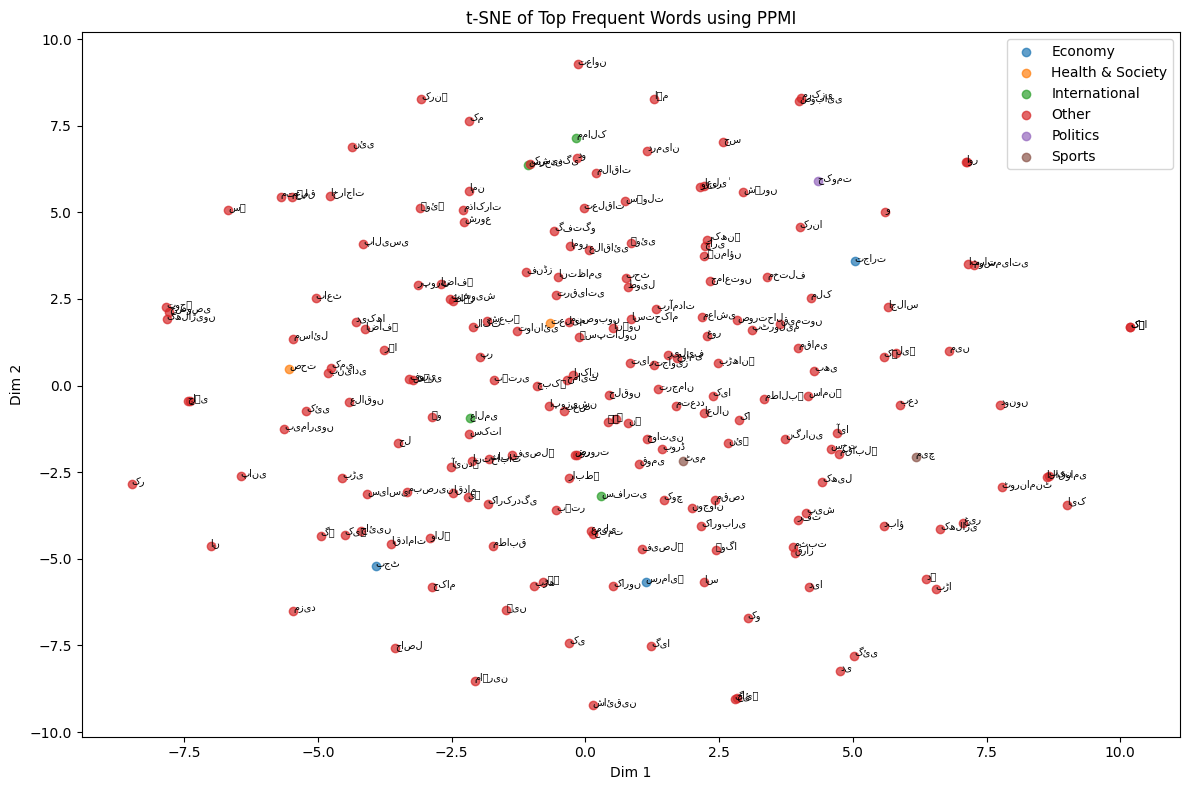

t-SNE saved: /content/i22-0452_Assignment2_AI-8A/figures/tsne_200_words.png

Top-5 nearest neighbours from PPMI
حکومت -> [('مسودہ', 0.3358), ('کاروباروں', 0.3127), ('بلدیاتی', 0.3124), ('نظام', 0.2973), ('درمیانے', 0.2675)]
پاکستان -> [('کھیلے', 0.6605), ('کرکٹ', 0.4505), ('گئے', 0.4363), ('لاہور', 0.4163), ('بورڈ', 0.3151)]
بجٹ -> [('اصلاحاتی', 0.3619), ('پارلیمنٹ', 0.3328), ('ناکافی', 0.3174), ('اقدامات', 0.2997), ('دیتے', 0.2961)]
ہسپتال -> not in vocab
ٹیم -> [('کرکٹ', 0.411), ('لاہور', 0.371), ('اننگز', 0.3627), ('بورڈ', 0.3435), ('حریف', 0.3388)]
تعلیم -> [('منصوبوں', 0.3661), ('ترقیاتی', 0.3325), ('توانائی', 0.3151), ('معاشرتی', 0.3073), ('انہوں', 0.2718)]
صحت -> [('بنیادی', 0.3786), ('غذائیت', 0.3421), ('محکمہ', 0.3267), ('گھر', 0.3215), ('سہولیات', 0.3121)]
پارلیمنٹ -> [('وزیراعظم', 0.447), ('ہیڈ', 0.3548), ('بجٹ', 0.3328), ('عہدیداروں', 0.3275), ('تبدیلیوں', 0.3031)]
کرکٹ -> [('لاہور', 0.5424), ('گئے', 0.4912), ('پاکستان', 0.4505), ('ٹیم', 0.411), ('کھیلے', 0.294)]
عالمی -> [

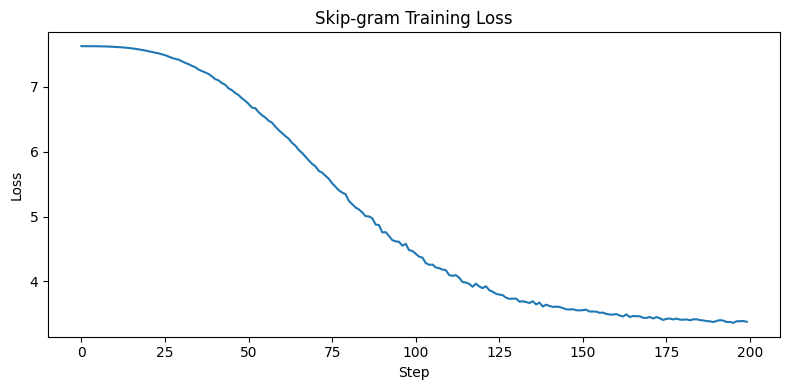

saved embeddings: /content/i22-0452_Assignment2_AI-8A/embeddings/embeddings_w2v.npy
saved loss curve: /content/i22-0452_Assignment2_AI-8A/figures/w2v_loss_curve.png
embedding shape: (671, 100)

2.2 Evaluation [7]

Top-10 nearest neighbours
Pakistan ( پاکستان ) -> [('ہاکی', 0.997), ('مہینوں', 0.9968), ('نہیں', 0.9966), ('ہمسایہ', 0.9965), ('ملا', 0.9965), ('بازار', 0.9964), ('ملکی', 0.9964), ('اقوام', 0.9964), ('ٹینس', 0.9963), ('وفاقی', 0.9962)]
Hukumat ( حکومت ) -> [('بجلی', 0.9806), ('حقوق', 0.9799), ('خطرات', 0.9798), ('اسکیم', 0.9796), ('کار', 0.9795), ('بازار', 0.9791), ('شکایات', 0.9791), ('حکمت', 0.9785), ('ہمسایہ', 0.9785), ('کرے', 0.9784)]
Adalat ( عدالت ) -> not in vocab
Maeeshat ( معیشت ) -> not in vocab
Fauj ( فوج ) -> not in vocab
Sehat ( صحت ) -> [('بغیر', 0.9787), ('ہفتوں', 0.9781), ('کانفرنس', 0.978), ('سلامتی', 0.978), ('دوطرفہ', 0.9779), ('تعینات', 0.9776), ('متحدہ', 0.9776), ('مسئلہ', 0.9776), ('حصص', 0.9775), ('ملا', 0.9775)]
Taleem ( تعلیم ) -> [('سینیٹ', 0.9931), 

In [18]:
import os
import json
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# main paths
BASE_DIR = "/content/i22-0452_Assignment2_AI-8A"
EMB_DIR = os.path.join(BASE_DIR, "embeddings")
DATA_DIR = os.path.join(BASE_DIR, "data")
FIG_DIR = os.path.join(BASE_DIR, "figures")

# make folders
os.makedirs(EMB_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# input files
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
RAW_PATH = os.path.join(BASE_DIR, "raw.txt")
META_PATH = os.path.join(BASE_DIR, "Metadata.json")

# output files
WORD2IDX_PATH = os.path.join(EMB_DIR, "word2idx.json")
TFIDF_PATH = os.path.join(EMB_DIR, "tfidf_matrix.npy")
PPMI_PATH = os.path.join(EMB_DIR, "ppmi_matrix.npy")
W2V_PATH = os.path.join(EMB_DIR, "embeddings_w2v.npy")
TSNE_PATH = os.path.join(FIG_DIR, "tsne_200_words.png")
LOSS_PATH = os.path.join(FIG_DIR, "w2v_loss_curve.png")

# seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# tokenizer
URDU_PUNCT = r"""[،۔؛؟!,:;"'()\[\]{}<>/\-—_…]"""
def tokenize(text):
    import re
    text = re.sub(f"({URDU_PUNCT})", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# load cleaned
with open(CLEANED_PATH, "r", encoding="utf-8") as f:
    cleaned_docs = [line.strip() for line in f if line.strip()]

# load raw
with open(RAW_PATH, "r", encoding="utf-8") as f:
    raw_docs = [line.strip() for line in f if line.strip()]

# load metadata
with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("cleaned docs:", len(cleaned_docs))
print("raw docs:", len(raw_docs))
print("metadata:", len(metadata))

# vocab limit
MAX_VOCAB = 10000

# special words
special_tokens = ["<PAD>", "<UNK>"]

# tokenize cleaned
cleaned_tokenized = [tokenize(doc) for doc in cleaned_docs]

# flatten cleaned
all_cleaned_tokens = [tok for doc in cleaned_tokenized for tok in doc]

# token counts
token_counts = Counter(all_cleaned_tokens)

# top vocab
most_common = [w for w, _ in token_counts.most_common(MAX_VOCAB)]

# final vocab
vocab = special_tokens + most_common

# maps
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# save vocab
with open(WORD2IDX_PATH, "w", encoding="utf-8") as f:
    json.dump(word2idx, f, ensure_ascii=False, indent=2)

print("vocab size:", len(word2idx))

# encode helper
def encode_tokens(tokens, w2i):
    unk = w2i["<UNK>"]
    return [w2i.get(t, unk) for t in tokens]

# cosine topk helper
def cosine_topk(query_word, matrix, w2i, i2w, top_k=5, skip_special=True):
    if query_word not in w2i:
        return []
    qid = w2i[query_word]
    qvec = matrix[qid].reshape(1, -1)
    sims = cosine_similarity(qvec, matrix)[0]
    ranked = np.argsort(sims)[::-1]
    ans = []
    for idx in ranked:
        if idx == qid:
            continue
        word = i2w[idx]
        if skip_special and word in ["<PAD>", "<UNK>"]:
            continue
        ans.append((word, round(float(sims[idx]), 4)))
        if len(ans) == top_k:
            break
    return ans

# topic-doc ids helper
def get_topic_doc_ids(metadata_list):
    topic_to_ids = defaultdict(list)
    for i, item in enumerate(metadata_list):
        topic_to_ids[item["category"]].append(i)
    return topic_to_ids

# print helper
def print_topic_words(topic_word_map):
    for topic, words in topic_word_map.items():
        print(topic)
        print(words)
        print()

# analogy helper
def analogy(word_a, word_b, word_c, emb_matrix, w2i, i2w, top_k=3):
    if word_a not in w2i or word_b not in w2i or word_c not in w2i:
        return []
    va = emb_matrix[w2i[word_a]]
    vb = emb_matrix[w2i[word_b]]
    vc = emb_matrix[w2i[word_c]]
    target = (vb - va + vc).reshape(1, -1)
    sims = cosine_similarity(target, emb_matrix)[0]
    banned = {w2i[word_a], w2i[word_b], w2i[word_c]}
    ranked = np.argsort(sims)[::-1]
    out = []
    for idx in ranked:
        if idx in banned:
            continue
        word = i2w[idx]
        if word in ["<PAD>", "<UNK>"]:
            continue
        out.append((word, round(float(sims[idx]), 4)))
        if len(out) == top_k:
            break
    return out

# rr helper
def reciprocal_rank(ranked_words, gold_word):
    for i, w in enumerate(ranked_words, start=1):
        if w == gold_word:
            return 1.0 / i
    return 0.0

# mrr helper
def compute_mrr(eval_pairs, matrix, w2i, i2w, top_k=50):
    scores = []
    for query_word, gold_word in eval_pairs:
        if query_word not in w2i or gold_word not in w2i:
            continue
        preds = cosine_topk(query_word, matrix, w2i, i2w, top_k=top_k)
        ranked_words = [w for w, _ in preds]
        scores.append(reciprocal_rank(ranked_words, gold_word))
    return round(float(np.mean(scores)), 4) if scores else 0.0

# 1.1 TF-IDF [4]
num_docs = len(cleaned_tokenized)
vocab_size = len(word2idx)

# tf matrix
tf_matrix = np.zeros((num_docs, vocab_size), dtype=np.float32)

# fill tf
for doc_id, tokens in enumerate(cleaned_tokenized):
    for token in tokens:
        tok_id = word2idx.get(token, word2idx["<UNK>"])
        tf_matrix[doc_id, tok_id] += 1

# df
df = np.sum(tf_matrix > 0, axis=0)

# idf
idf = np.log(num_docs / (1 + df))

# tfidf
tfidf_matrix = tf_matrix * idf

# zero pad
if "<PAD>" in word2idx:
    tfidf_matrix[:, word2idx["<PAD>"]] = 0.0

# save tfidf
np.save(TFIDF_PATH, tfidf_matrix)

print("\n1.1 TF-IDF [4]")
print("tfidf shape:", tfidf_matrix.shape)
print("saved:", TFIDF_PATH)

# group by topic
topic_to_doc_ids = get_topic_doc_ids(metadata)

# ignore ids
ignore_ids = set()
if "<PAD>" in word2idx:
    ignore_ids.add(word2idx["<PAD>"])
if "<UNK>" in word2idx:
    ignore_ids.add(word2idx["<UNK>"])

# top words
topic_top_words = {}
for topic, doc_ids in topic_to_doc_ids.items():
    topic_scores = tfidf_matrix[doc_ids].mean(axis=0)
    ranked_ids = np.argsort(topic_scores)[::-1]
    top_words = []
    for idx in ranked_ids:
        if idx in ignore_ids:
            continue
        top_words.append((idx2word[idx], round(float(topic_scores[idx]), 4)))
        if len(top_words) == 10:
            break
    topic_top_words[topic] = top_words

print("\nTop-10 discriminative words per topic")
print_topic_words(topic_top_words)

# 1.2 PPMI [5]
window_size = 5

# cooc matrix
cooc_matrix = np.zeros((vocab_size, vocab_size), dtype=np.float32)

# fill cooc
for tokens in cleaned_tokenized:
    token_ids = encode_tokens(tokens, word2idx)
    for center_pos, center_id in enumerate(token_ids):
        left = max(0, center_pos - window_size)
        right = min(len(token_ids), center_pos + window_size + 1)
        for ctx_pos in range(left, right):
            if ctx_pos == center_pos:
                continue
            context_id = token_ids[ctx_pos]
            cooc_matrix[center_id, context_id] += 1.0

# zero pad row col
if "<PAD>" in word2idx:
    pad_id = word2idx["<PAD>"]
    cooc_matrix[pad_id, :] = 0
    cooc_matrix[:, pad_id] = 0

# totals
total_count = np.sum(cooc_matrix)
word_counts = np.sum(cooc_matrix, axis=1)
context_counts = np.sum(cooc_matrix, axis=0)

# ppmi matrix
ppmi_matrix = np.zeros_like(cooc_matrix, dtype=np.float32)

# fill ppmi
for i in range(vocab_size):
    for j in range(vocab_size):
        if cooc_matrix[i, j] == 0:
            continue
        p_ij = cooc_matrix[i, j] / total_count
        p_i = word_counts[i] / total_count
        p_j = context_counts[j] / total_count
        pmi = math.log2(p_ij / (p_i * p_j))
        ppmi_matrix[i, j] = max(0.0, pmi)

# save ppmi
np.save(PPMI_PATH, ppmi_matrix)

print("1.2 PPMI [5]")
print("ppmi shape:", ppmi_matrix.shape)
print("saved:", PPMI_PATH)

# t-SNE labels
top_200_words = [w for w, _ in token_counts.most_common(min(200, len(token_counts)))]
top_200_ids = [word2idx[w] for w in top_200_words if w in word2idx]
top_200_vectors = ppmi_matrix[top_200_ids]

# rough semantic labels
topic_seed_words = {
    "Politics": ["حکومت", "پارلیمنٹ", "وزیراعظم", "انتخاب", "کابینہ"],
    "Sports": ["کرکٹ", "میچ", "ٹیم", "کپتان", "گول"],
    "Economy": ["بجٹ", "مہنگائی", "بینک", "تجارت", "سرمایہ"],
    "International": ["اقوام", "سفارتی", "ممالک", "سرحدی", "عالمی"],
    "Health & Society": ["ہسپتال", "ویکسین", "تعلیم", "صحت", "بیماری"]
}

# label helper
def assign_semantic_label(word):
    for label, seeds in topic_seed_words.items():
        if word in seeds:
            return label
    return "Other"

# t-SNE plot
if len(top_200_ids) >= 2:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(top_200_ids)-1))
    coords = tsne.fit_transform(top_200_vectors)

    labels = [assign_semantic_label(w) for w in top_200_words[:len(coords)]]
    unique_labels = sorted(set(labels))

    plt.figure(figsize=(12, 8))
    for label in unique_labels:
        xs = [coords[i, 0] for i in range(len(coords)) if labels[i] == label]
        ys = [coords[i, 1] for i in range(len(coords)) if labels[i] == label]
        plt.scatter(xs, ys, label=label, alpha=0.7)

    for i, word in enumerate(top_200_words[:len(coords)]):
        plt.text(coords[i, 0], coords[i, 1], word, fontsize=7)

    plt.title("t-SNE of Top Frequent Words using PPMI")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(TSNE_PATH, dpi=200)
    plt.show()

    print("t-SNE saved:", TSNE_PATH)

# ppmi queries
query_words_ppmi = ["حکومت", "پاکستان", "بجٹ", "ہسپتال", "ٹیم", "تعلیم", "صحت", "پارلیمنٹ", "کرکٹ", "عالمی"]

print("\nTop-5 nearest neighbours from PPMI")
for word in query_words_ppmi:
    if word in word2idx:
        print(word, "->", cosine_topk(word, ppmi_matrix, word2idx, idx2word, top_k=5))
    else:
        print(word, "-> not in vocab")

# 2.1 Skip-gram Word2Vec [9]
class SkipGramDataset(Dataset):
    def __init__(self, docs, w2i, window_size=5):
        self.pairs = []
        for tokens in docs:
            ids = encode_tokens(tokens, w2i)
            for center_pos, center_id in enumerate(ids):
                left = max(0, center_pos - window_size)
                right = min(len(ids), center_pos + window_size + 1)
                for ctx_pos in range(left, right):
                    if ctx_pos == center_pos:
                        continue
                    self.pairs.append((center_id, ids[ctx_pos]))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]

class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.center_emb = nn.Embedding(vocab_size, emb_dim)
        self.context_emb = nn.Embedding(vocab_size, emb_dim)
        nn.init.uniform_(self.center_emb.weight, -0.5/emb_dim, 0.5/emb_dim)
        nn.init.uniform_(self.context_emb.weight, -0.5/emb_dim, 0.5/emb_dim)

    def forward(self, center_words, pos_words, neg_words):
        v = self.center_emb(center_words)
        u_pos = self.context_emb(pos_words)
        u_neg = self.context_emb(neg_words)

        pos_score = torch.sum(v * u_pos, dim=1)
        pos_loss = F.logsigmoid(pos_score)

        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1)

        loss = -(pos_loss + neg_loss).mean()
        return loss

# noise dist
def build_noise_dist(token_counts_map, w2i):
    freqs = np.zeros(len(w2i), dtype=np.float64)
    for word, idx in w2i.items():
        freqs[idx] = token_counts_map.get(word, 0)
    freqs = np.power(freqs, 0.75)
    total = freqs.sum()
    if total == 0:
        freqs += 1.0
        total = freqs.sum()
    return freqs / total

# train function
def train_skipgram(tokenized_docs_local, token_counts_local, w2i, emb_dim=100, window_size=5, num_neg=10, lr=0.001, epochs=5, batch_size=512):
    dataset = SkipGramDataset(tokenized_docs_local, w2i, window_size=window_size)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = SkipGramNegSampling(len(w2i), emb_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    noise_dist = build_noise_dist(token_counts_local, w2i)
    noise_dist_t = torch.tensor(noise_dist, dtype=torch.float32, device=device)

    loss_history = []

    for epoch in range(epochs):
        running_loss = 0.0
        for batch in loader:
            centers = batch[0].to(device)
            pos_words = batch[1].to(device)

            neg_words = torch.multinomial(noise_dist_t, centers.size(0) * num_neg, replacement=True)
            neg_words = neg_words.view(centers.size(0), num_neg)

            optimizer.zero_grad()
            loss = model(centers, pos_words, neg_words)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loss_history.append(loss.item())

        avg_loss = running_loss / max(1, len(loader))
        print(f"epoch {epoch+1}/{epochs} loss: {avg_loss:.4f}")

    with torch.no_grad():
        V = model.center_emb.weight.detach().cpu().numpy()
        U = model.context_emb.weight.detach().cpu().numpy()
        final_emb = 0.5 * (V + U)

    return model, final_emb, loss_history

print("\n2.1 Skip-gram Word2Vec [9]")

model_c3, embeddings_w2v, loss_history = train_skipgram(
    tokenized_docs_local=cleaned_tokenized,
    token_counts_local=token_counts,
    w2i=word2idx,
    emb_dim=100,
    window_size=5,
    num_neg=10,
    lr=0.001,
    epochs=5,
    batch_size=512
)

# save final emb
np.save(W2V_PATH, embeddings_w2v)

# loss plot
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Skip-gram Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig(LOSS_PATH, dpi=200)
plt.show()

print("saved embeddings:", W2V_PATH)
print("saved loss curve:", LOSS_PATH)
print("embedding shape:", embeddings_w2v.shape)

# 2.2 Evaluation [7]
print("\n2.2 Evaluation [7]")

# query mapping
query_words_w2v = ["Pakistan", "Hukumat", "Adalat", "Maeeshat", "Fauj", "Sehat", "Taleem", "Aabadi"]
translit_map = {
    "Pakistan": "پاکستان",
    "Hukumat": "حکومت",
    "Adalat": "عدالت",
    "Maeeshat": "معیشت",
    "Fauj": "فوج",
    "Sehat": "صحت",
    "Taleem": "تعلیم",
    "Aabadi": "آبادی"
}

print("\nTop-10 nearest neighbours")
for q in query_words_w2v:
    actual = translit_map[q]
    if actual in word2idx:
        print(q, "(", actual, ")", "->", cosine_topk(actual, embeddings_w2v, word2idx, idx2word, top_k=10))
    else:
        print(q, "(", actual, ")", "-> not in vocab")

# analogy tests
analogy_tests = [
    ("مرد", "عورت", "بادشاہ"),
    ("استاد", "اسکول", "ڈاکٹر"),
    ("پاکستان", "اسلام آباد", "بھارت"),
    ("کرکٹ", "بیٹ", "فٹبال"),
    ("ہسپتال", "ڈاکٹر", "عدالت"),
    ("بجٹ", "معیشت", "میچ"),
    ("پارلیمنٹ", "حکومت", "عدالت"),
    ("لاہور", "پاکستان", "دہلی"),
    ("وزیراعظم", "حکومت", "کپتان"),
    ("تعلیم", "اسکول", "صحت")
]

print("\nTop-3 analogy candidates")
for a, b, c in analogy_tests:
    result = analogy(a, b, c, embeddings_w2v, word2idx, idx2word, top_k=3)
    print(f"{a} : {b} :: {c} : ? -> {result}")

print("\nEmbedding quality note")
print("With a small custom corpus, semantic quality may be limited.")
print("If neighbours are topic-related and analogies show partial consistency, the embeddings still capture useful patterns.")

# 2.2 Four-condition comparison [3]
print("\nFour-condition comparison")

# raw tokenized
raw_tokenized = [tokenize(doc) for doc in raw_docs]
all_raw_tokens = [tok for doc in raw_tokenized for tok in doc]
raw_counts = Counter(all_raw_tokens)

# C1
c1_matrix = ppmi_matrix

# C2
_, c2_emb, _ = train_skipgram(
    tokenized_docs_local=raw_tokenized,
    token_counts_local=raw_counts,
    w2i=word2idx,
    emb_dim=100,
    window_size=5,
    num_neg=10,
    lr=0.001,
    epochs=5,
    batch_size=512
)

# C3
c3_matrix = embeddings_w2v

# C4
_, c4_emb, _ = train_skipgram(
    tokenized_docs_local=cleaned_tokenized,
    token_counts_local=token_counts,
    w2i=word2idx,
    emb_dim=200,
    window_size=5,
    num_neg=10,
    lr=0.001,
    epochs=5,
    batch_size=512
)

# manual pairs
manual_pairs = [
    ("حکومت", "پارلیمنٹ"),
    ("بجٹ", "معیشت"),
    ("کرکٹ", "ٹیم"),
    ("ہسپتال", "صحت"),
    ("تعلیم", "اسکول"),
    ("عالمی", "ممالک"),
    ("سفارتی", "اقوام"),
    ("مہنگائی", "قیمتوں"),
    ("کپتان", "میچ"),
    ("ڈاکٹر", "ہسپتال"),
    ("لاہور", "پاکستان"),
    ("گول", "فٹبال"),
    ("بینک", "شرح"),
    ("کابینہ", "وزیراعظم"),
    ("امداد", "سیلاب"),
    ("سرحدی", "کشیدگی"),
    ("پالیسی", "بینک"),
    ("ٹیم", "شائقین"),
    ("شہری", "آلودگی"),
    ("خواتین", "صحت")
]

# compare queries
compare_queries = ["حکومت", "بجٹ", "کرکٹ", "ہسپتال", "عالمی"]

# condition map
conditions = {
    "C1_PPMI": c1_matrix,
    "C2_W2V_raw": c2_emb,
    "C3_W2V_cleaned": c3_matrix,
    "C4_W2V_d200": c4_emb
}

# print compare
for name, mat in conditions.items():
    print("\n", name)
    for q in compare_queries:
        if q in word2idx:
            print(q, "->", cosine_topk(q, mat, word2idx, idx2word, top_k=5))
        else:
            print(q, "-> not in vocab")
    mrr = compute_mrr(manual_pairs, mat, word2idx, idx2word, top_k=50)
    print("MRR:", mrr)

print("\nPart 1 done")

Device: cpu
cleaned docs: 50
metadata: 50
vocab size: 671
has w2v: True

3. Dataset Preparation [5]
total sentences found: 150

sentences per topic
Politics : 30
Sports : 30
Economy : 30
International : 30
Health & Society : 30
selected sentences: 150
major topics used: ['Politics', 'Sports', 'Economy']
annotated sentences: 150
train: 105
val: 20
test: 25

topic distribution in train
Sports : 21
Politics : 21
Economy : 21
International : 21
Health & Society : 21

topic distribution in val
Sports : 4
Economy : 4
International : 4
Health & Society : 4
Politics : 4

topic distribution in test
International : 5
Sports : 5
Politics : 5
Health & Society : 5
Economy : 5

POS label distribution train
Counter({'NOUN': 603, 'VERB': 212, 'POST': 210, 'ADJ': 168, 'UNK': 85, 'PRON': 75, 'CONJ': 53, 'DET': 18, 'PUNC': 15, 'ADV': 11})

NER label distribution train
Counter({'O': 1430, 'B-MISC': 11, 'B-ORG': 4, 'I-ORG': 3, 'B-LOC': 2})

saved
/content/i22-0452_Assignment2_AI-8A/data/pos_train.conll
/co

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


NER epoch 2 train_loss=16.3789 val_loss=5.0147 val_f1=0.0000
NER epoch 3 train_loss=2.0795 val_loss=5.6555 val_f1=0.0000
NER epoch 4 train_loss=2.1731 val_loss=5.5083 val_f1=0.0000
NER epoch 5 train_loss=2.1090 val_loss=4.9194 val_f1=0.0000
NER epoch 6 train_loss=1.7456 val_loss=4.1840 val_f1=0.0000
NER early stop

NER with CRF fine-tuned
NER epoch 1 train_loss=28.6990 val_loss=21.5214 val_f1=0.0000
NER epoch 2 train_loss=9.9928 val_loss=3.5223 val_f1=0.0000
NER epoch 3 train_loss=1.6635 val_loss=4.2877 val_f1=0.0000
NER epoch 4 train_loss=1.5701 val_loss=3.9630 val_f1=0.0000
NER epoch 5 train_loss=1.6672 val_loss=3.3574 val_f1=0.0000
NER epoch 6 train_loss=1.3391 val_loss=2.7014 val_f1=0.0000
NER early stop

NER without CRF
NER epoch 1 train_loss=1.9787 val_loss=1.5319 val_f1=0.0000
NER epoch 2 train_loss=0.7461 val_loss=0.2446 val_f1=0.0000
NER epoch 3 train_loss=0.1254 val_loss=0.3375 val_f1=0.0000
NER epoch 4 train_loss=0.1289 val_loss=0.3293 val_f1=0.0000
NER epoch 5 train_loss=0.

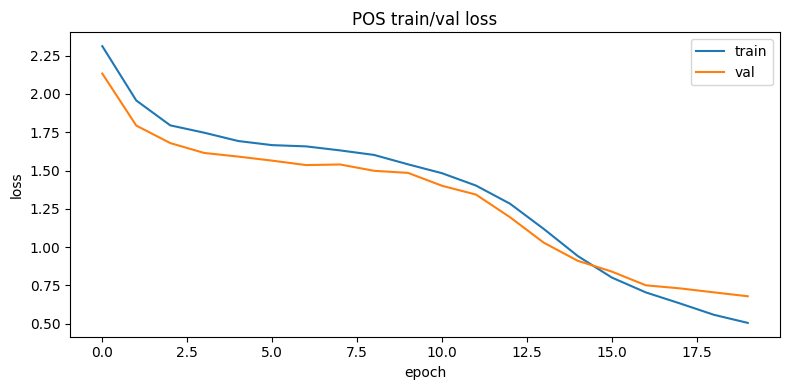

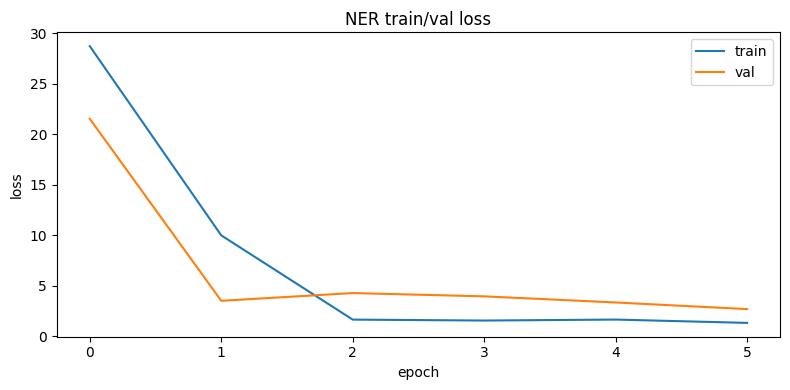


5.1 POS Tagging [4]
POS frozen acc: 0.4891
POS frozen macro-f1: 0.1333
POS fine-tuned acc: 0.7103
POS fine-tuned macro-f1: 0.4679

POS confusion matrix
[[76  8 38  0  0  0  0  6  0  0  0]
 [ 0 51  0  0  0  0  0  2  0  0  0]
 [ 7  1 28  0  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0]
 [ 0  1  0  0  2  0  3  0  0  0  4]
 [ 0  0  0  0  1  0  3  0  0  0  0]
 [ 0  0  0  0  0  0  9  0  0  0  0]
 [ 0  5  7  0  0  0  0 45  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  2  0  0  0  0]
 [ 0  1  0  0  0  0  1  0  0  0 17]]

Top 3 confused pairs
('NOUN', 'ADJ') : 38
('NOUN', 'VERB') : 8
('ADJ', 'NOUN') : 7

Examples for confused pairs
NOUN -> ADJ
اقوام متحدہ کے اجلاس میں عالمی امن، انسانی حقوق اور سرحدی کشیدگی کے مسائل پر گفتگو ہوئی
قومی پرچم اور نعروں نے ماحول کو مزید پرجوش بنا دیا

NOUN -> VERB
اقوام متحدہ کے اجلاس میں عالمی امن، انسانی حقوق اور سرحدی کشیدگی کے مسائل پر گفتگو ہوئی
قومی پرچم اور نعروں نے ماحول کو مزید پرجوش بنا دیا

ADJ -> NOUN
قومی پرچم اور نعروں 

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


POS epoch 1 train_loss=2.3794 val_loss=2.2958 val_f1=0.0612
POS epoch 2 train_loss=2.1755 val_loss=1.9138 val_f1=0.0545
POS epoch 3 train_loss=1.9247 val_loss=1.8028 val_f1=0.0597
POS epoch 4 train_loss=1.8939 val_loss=1.7832 val_f1=0.0597
POS early stop
NER epoch 1 train_loss=37.8378 val_loss=33.9852 val_f1=0.0568
NER epoch 2 train_loss=28.4937 val_loss=16.7577 val_f1=0.0656
NER epoch 3 train_loss=11.6695 val_loss=7.6355 val_f1=0.0000
NER epoch 4 train_loss=5.7395 val_loss=6.5597 val_f1=0.0000
NER epoch 5 train_loss=4.2483 val_loss=6.3665 val_f1=0.0000
NER early stop

A2 No dropout
POS epoch 1 train_loss=2.2960 val_loss=2.1109 val_f1=0.0597
POS epoch 2 train_loss=1.9505 val_loss=1.7535 val_f1=0.0597
POS epoch 3 train_loss=1.7676 val_loss=1.6680 val_f1=0.1290
POS epoch 4 train_loss=1.7187 val_loss=1.5998 val_f1=0.1320
POS epoch 5 train_loss=1.6664 val_loss=1.5632 val_f1=0.1279
POS epoch 6 train_loss=1.6337 val_loss=1.5438 val_f1=0.1279
POS epoch 7 train_loss=1.6069 val_loss=1.5152 val_

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


NER epoch 3 train_loss=1.7240 val_loss=3.9284 val_f1=0.0000
NER epoch 4 train_loss=1.7617 val_loss=3.6903 val_f1=0.0000
NER early stop

A3 Random embeddings
POS epoch 1 train_loss=2.3376 val_loss=2.1557 val_f1=0.0597
POS epoch 2 train_loss=1.9516 val_loss=1.8144 val_f1=0.0597
POS epoch 3 train_loss=1.7956 val_loss=1.6602 val_f1=0.1273
POS epoch 4 train_loss=1.7246 val_loss=1.6186 val_f1=0.1279
POS epoch 5 train_loss=1.6869 val_loss=1.5898 val_f1=0.1271
POS epoch 6 train_loss=1.6655 val_loss=1.5496 val_f1=0.1279
POS epoch 7 train_loss=1.6434 val_loss=1.5306 val_f1=0.1342
POS epoch 8 train_loss=1.6228 val_loss=1.4956 val_f1=0.1311
POS epoch 9 train_loss=1.5773 val_loss=1.4495 val_f1=0.1387
POS epoch 10 train_loss=1.5147 val_loss=1.3765 val_f1=0.1344
NER epoch 1 train_loss=39.5154 val_loss=32.1978 val_f1=0.0000


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


NER epoch 2 train_loss=17.6080 val_loss=3.6946 val_f1=0.0000
NER epoch 3 train_loss=1.5804 val_loss=4.3735 val_f1=0.0000
NER epoch 4 train_loss=1.7240 val_loss=4.5709 val_f1=0.0000
NER early stop

A4 Softmax instead of CRF
NER epoch 1 train_loss=1.9519 val_loss=1.5185 val_f1=0.0000
NER epoch 2 train_loss=0.7438 val_loss=0.2436 val_f1=0.0000
NER epoch 3 train_loss=0.1061 val_loss=0.3363 val_f1=0.0000
NER epoch 4 train_loss=0.1375 val_loss=0.3259 val_f1=0.0000
NER early stop

Ablation results
{'A1': {'pos_val_f1': 0.0612, 'ner_val_f1': np.float64(0.0656)}, 'A2': {'pos_val_f1': 0.132, 'ner_val_f1': np.float64(0.0)}, 'A3': {'pos_val_f1': 0.1387, 'ner_val_f1': np.float64(0.0)}, 'A4': {'ner_val_f1': np.float64(0.0)}}

Short findings
A1 tests value of backward context.
A2 tests effect of dropout.
A3 tests value of pretrained embeddings from Part 1.
A4 tests whether CRF improves structured NER decoding.

Part 2 done


In [19]:
import os
import re
import json
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

try:
    from seqeval.metrics import precision_score as ner_precision_score
    from seqeval.metrics import recall_score as ner_recall_score
    from seqeval.metrics import f1_score as ner_f1_score
    from seqeval.metrics import classification_report as ner_classification_report
except:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seqeval"])
    from seqeval.metrics import precision_score as ner_precision_score
    from seqeval.metrics import recall_score as ner_recall_score
    from seqeval.metrics import f1_score as ner_f1_score
    from seqeval.metrics import classification_report as ner_classification_report

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

BASE_DIR = "/content/i22-0452_Assignment2_AI-8A"
EMB_DIR = os.path.join(BASE_DIR, "embeddings")
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH = os.path.join(BASE_DIR, "Metadata.json")
WORD2IDX_PATH = os.path.join(EMB_DIR, "word2idx.json")
W2V_PATH = os.path.join(EMB_DIR, "embeddings_w2v.npy")

POS_TRAIN_PATH = os.path.join(DATA_DIR, "pos_train.conll")
POS_TEST_PATH = os.path.join(DATA_DIR, "pos_test.conll")
NER_TRAIN_PATH = os.path.join(DATA_DIR, "ner_train.conll")
NER_TEST_PATH = os.path.join(DATA_DIR, "ner_test.conll")

POS_MODEL_PATH = os.path.join(MODEL_DIR, "bilstm_pos.pt")
NER_MODEL_PATH = os.path.join(MODEL_DIR, "bilstm_ner.pt")

POS_LOSS_PATH = os.path.join(FIG_DIR, "pos_loss.png")
NER_LOSS_PATH = os.path.join(FIG_DIR, "ner_loss.png")
POS_CM_PATH = os.path.join(FIG_DIR, "pos_confusion_matrix.npy")

with open(CLEANED_PATH, "r", encoding="utf-8") as f:
    cleaned_docs = [line.strip() for line in f if line.strip()]

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(WORD2IDX_PATH, "r", encoding="utf-8") as f:
    word2idx = json.load(f)

idx2word = {int(v): k for k, v in word2idx.items()}

if os.path.exists(W2V_PATH):
    embeddings_w2v = np.load(W2V_PATH)
else:
    embeddings_w2v = None

print("cleaned docs:", len(cleaned_docs))
print("metadata:", len(metadata))
print("vocab size:", len(word2idx))
print("has w2v:", embeddings_w2v is not None)

URDU_PUNCT = r"""[،۔؛؟!,:;"'()\[\]{}<>/\-—_…]"""

def tokenize(text):
    text = re.sub(f"({URDU_PUNCT})", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def split_sentences(text):
    parts = re.split(r"[۔!?؟]+", text)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

def stem_urdu(token):
    suffixes = ["وں", "یں", "ان", "ات", "گی", "یاں", "وں", "ے", "ی", "ا", "ت", "ھیں", "ہیں", "گا", "گی", "گے"]
    for suf in sorted(set(suffixes), key=len, reverse=True):
        if token.endswith(suf) and len(token) > len(suf) + 2:
            return token[:-len(suf)]
    return token

# 3. Dataset Preparation [5]

article_units = []
for i, doc in enumerate(cleaned_docs):
    topic = metadata[i]["category"] if i < len(metadata) else "Unknown"
    sents = split_sentences(doc)
    for sent in sents:
        toks = tokenize(sent)
        if len(toks) >= 3:
            article_units.append({
                "sentence": sent,
                "tokens": toks,
                "topic": topic,
                "doc_id": i
            })

print("\n3. Dataset Preparation [5]")
print("total sentences found:", len(article_units))

topic_to_sent_ids = defaultdict(list)
for i, item in enumerate(article_units):
    topic_to_sent_ids[item["topic"]].append(i)

print("\nsentences per topic")
for k, v in topic_to_sent_ids.items():
    print(k, ":", len(v))

target_total = 500
target_per_major = 100

major_topics = sorted(topic_to_sent_ids.keys(), key=lambda x: len(topic_to_sent_ids[x]), reverse=True)[:3]
selected_ids = []

for topic in major_topics:
    ids = topic_to_sent_ids[topic]
    take = min(target_per_major, len(ids))
    selected_ids.extend(random.sample(ids, take))

remaining_pool = [i for i in range(len(article_units)) if i not in set(selected_ids)]
remaining_needed = max(0, target_total - len(selected_ids))

if remaining_needed > 0:
    take_more = min(remaining_needed, len(remaining_pool))
    selected_ids.extend(random.sample(remaining_pool, take_more))

selected_ids = sorted(set(selected_ids))
selected_data = [article_units[i] for i in selected_ids]

if len(selected_data) < 500:
    print("warning: fewer than 500 sentences available, using", len(selected_data))

print("selected sentences:", len(selected_data))
print("major topics used:", major_topics)

# POS lexicons
PRON_SET = {
    "میں","ہم","تم","آپ","وہ","یہ","تو","تمہیں","ہمیں","اسے","انہیں","اس","ان","میرا","میری","میرے",
    "ہمارا","ہماری","ہمارے","آپکا","آپکی","آپکے","تمہارا","تمہاری","تمہارے","خود","اپنے","اپنی","اپنا"
}
DET_SET = {
    "ایک","یہ","وہ","اس","ان","ہر","کچھ","تمام","چند","کئی","اسی","ایسے","ایسی","ایسا","سب","کم","زیادہ"
}
CONJ_SET = {
    "اور","یا","لیکن","مگر","بلکہ","اگر","تو","کیونکہ","جبکہ","کہ","تاکہ","ورنہ","نیز","سو","پس"
}
POST_SET = {
    "میں","پر","سے","کو","کا","کی","کے","تک","بعد","قبل","لیے","لئے","ساتھ","بنا","بغیر","اندر","باہر","اوپر","نیچے","درمیان"
}
ADV_SET = {
    "آج","کل","اب","تب","پھر","یہاں","وہاں","ہمیشہ","کبھی","اکثر","بھی","فوراً","جلد","بعد","پہلے","کم","زیادہ","مزید"
}
VERB_SEEDS = {
    "ہے","ہیں","تھا","تھی","تھے","ہو","ہوا","ہوئی","ہوئے","کیا","کی","کیے","کر","کرتا","کرتی","کرتے",
    "گیا","گئی","گئے","جائے","جاتا","جاتی","جاتے","دیا","دی","دیے","لیا","لی","لیے","رہا","رہی","رہے",
    "کہا","بتایا","اعلان","شروع","دیکھا","رکھا","بنایا","ہوتا","ہوتی","ہوتے","چاہیے","سکتا","سکتے","سکتی"
}
ADJ_SEEDS = {
    "اہم","نیا","نئی","بڑا","بڑی","بہتر","کم","زیادہ","عالمی","قومی","مقامی","سیاسی","اقتصادی","سماجی","طبی",
    "سرحدی","انسانی","مالی","شفاف","مشترکہ","فیصلہ","مثبت","منفی","موسمی","تعلیمی","صحت","صنعتی"
}
NOUN_SEEDS = {
    "حکومت","پارلیمنٹ","میچ","ٹیم","بجٹ","معیشت","ہسپتال","صحت","تعلیم","قیمت","بازار","ملک","ممالک","وزیراعظم",
    "وزیراعلیٰ","اسمبلی","کابینہ","کرکٹ","فٹبال","بینک","مارکیٹ","مریض","ڈاکٹر","اسکول","شہر","علاقہ","ادارہ"
}
PUNC_SET = {"،","۔","؟","!",";",":","(",")","[","]","{","}","\"","'"}
NUM_RE = re.compile(r"^\d+$")

def is_verb(token):
    if token in VERB_SEEDS:
        return True
    return token.endswith(("نا","تا","تی","تے","گا","گی","گے","رہا","رہی","رہے"))

def is_adj(token):
    if token in ADJ_SEEDS:
        return True
    return token.endswith(("ی","دار","انہ","آمیز"))

def pos_tag_token(token):
    if token in PUNC_SET:
        return "PUNC"
    if NUM_RE.match(token):
        return "NUM"
    if token in PRON_SET:
        return "PRON"
    if token in DET_SET:
        return "DET"
    if token in CONJ_SET:
        return "CONJ"
    if token in POST_SET:
        return "POST"
    if token in ADV_SET:
        return "ADV"
    if is_verb(token):
        return "VERB"
    if is_adj(token):
        return "ADJ"
    if token in NOUN_SEEDS or len(token) > 2:
        return "NOUN"
    return "UNK"

POS_TAGS = ["NOUN","VERB","ADJ","ADV","PRON","DET","CONJ","POST","NUM","PUNC","UNK"]
pos2idx = {t:i for i,t in enumerate(POS_TAGS)}
idx2pos = {i:t for t,i in pos2idx.items()}

# NER gazetteers
PERSONS = {
    "عمران خان","نواز شریف","شہباز شریف","بلاول بھٹو","آصف زرداری","مریم نواز","پرویز الٰہی","چوہدری شجاعت",
    "فضل الرحمن","مولانا فضل الرحمن","پرویز خٹک","حمزہ شہباز","خواجہ آصف","اسحاق ڈار","شیری رحمان",
    "فردوس عاشق اعوان","اعتزاز احسن","سراج الحق","سعد رفیق","رانا ثنا اللہ","یوسف رضا گیلانی","شاہد خاقان عباسی",
    "شاہ محمود قریشی","فواد چوہدری","مونس الٰہی","اقبال ظفر جھگڑا","ناصر شاہ","عاطف خان","مراد سعید",
    "علی محمد خان","وقار یونس","بابر اعظم","شاہد آفریدی","وسیم اکرم","ثناء میر","بسمہ معروف","محمد رضوان",
    "فخر زمان","حارث رؤف","نسیم شاہ","سجاد علی","عابد علی","سرفراز احمد","مصباح الحق","انضمام الحق",
    "کامران اکمل","سعید انور","یونس خان","عبدالقادر","جاوید میانداد","ثقلین مشتاق","راشد لطیف","عمر گل"
}

LOCATIONS = {
    "پاکستان","اسلام آباد","لاہور","کراچی","پشاور","کوئٹہ","راولپنڈی","فیصل آباد","ملتان","حیدر آباد",
    "سکھر","گلگت","سکردو","مری","ڈی آئی خان","بہاولپور","گوجرانوالہ","سیالکوٹ","سرگودھا","جہلم",
    "اٹک","چکوال","کوہاٹ","مردان","صوابی","چارسدہ","نوشہرہ","ایبٹ آباد","مانسہرہ","مظفر آباد",
    "میرپور","گلگت بلتستان","آزاد کشمیر","پنجاب","سندھ","بلوچستان","خیبر پختونخوا","جنوبی وزیرستان","شمالی وزیرستان",
    "افغانستان","بھارت","چین","امریکہ","برطانیہ","ایران","ترکی","سعودی عرب","قطر","دبئی","دوحہ","کابل","دہلی","بیجنگ"
}

ORGS = {
    "اقوام متحدہ","پی ٹی آئی","مسلم لیگ","مسلم لیگ ن","پیپلز پارٹی","ایم کیو ایم","جماعت اسلامی","الیکشن کمیشن",
    "قومی اسمبلی","سینیٹ","سپریم کورٹ","ہائی کورٹ","اسٹیٹ بینک","پاکستان کرکٹ بورڈ","آئی سی سی","ورلڈ بینک",
    "آئی ایم ایف","وزارت صحت","وزارت تعلیم","محکمہ صحت","پولیس","پاک فوج","نیب","ریسکیو 1122","پی آئی اے",
    "نادرا","واپڈا","پاکستان اسٹیل","ایف بی آر","سی ڈی اے","محکمہ تعلیم"
}

MISC = {
    "کورونا","ڈینگی","فلو","ویکسین","سیلاب","زلزلہ","بجٹ","تعلیم","صحت","کرکٹ","فٹبال","ہاکی"
}

NER_TAGS = ["B-PER","I-PER","B-LOC","I-LOC","B-ORG","I-ORG","B-MISC","I-MISC","O"]
ner2idx = {t:i for i,t in enumerate(NER_TAGS)}
idx2ner = {i:t for t,i in ner2idx.items()}

def build_phrase_map(items, prefix):
    mp = {}
    for phrase in items:
        toks = tokenize(phrase)
        if len(toks) > 0:
            mp[tuple(toks)] = prefix
    return mp

person_map = build_phrase_map(PERSONS, "PER")
loc_map = build_phrase_map(LOCATIONS, "LOC")
org_map = build_phrase_map(ORGS, "ORG")
misc_map = build_phrase_map(MISC, "MISC")

all_phrase_maps = {}
all_phrase_maps.update(person_map)
all_phrase_maps.update(loc_map)
all_phrase_maps.update(org_map)
all_phrase_maps.update(misc_map)

max_phrase_len = max(len(k) for k in all_phrase_maps.keys())

def ner_tag_sentence(tokens):
    tags = ["O"] * len(tokens)
    i = 0
    while i < len(tokens):
        matched = False
        for L in range(max_phrase_len, 0, -1):
            if i + L > len(tokens):
                continue
            chunk = tuple(tokens[i:i+L])
            if chunk in all_phrase_maps:
                lab = all_phrase_maps[chunk]
                tags[i] = f"B-{lab}"
                for j in range(i+1, i+L):
                    tags[j] = f"I-{lab}"
                i += L
                matched = True
                break
        if not matched:
            i += 1
    return tags

annotated_data = []
for item in selected_data:
    tokens = item["tokens"]
    pos_tags = [pos_tag_token(tok) for tok in tokens]
    ner_tags = ner_tag_sentence(tokens)
    annotated_data.append({
        "tokens": tokens,
        "pos_tags": pos_tags,
        "ner_tags": ner_tags,
        "topic": item["topic"],
        "sentence": item["sentence"]
    })

print("annotated sentences:", len(annotated_data))

def stratified_split(records, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    by_topic = defaultdict(list)
    for r in records:
        by_topic[r["topic"]].append(r)

    train_data, val_data, test_data = [], [], []

    for topic, rows in by_topic.items():
        random.shuffle(rows)
        n = len(rows)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        train_data.extend(rows[:n_train])
        val_data.extend(rows[n_train:n_train+n_val])
        test_data.extend(rows[n_train+n_val:])

    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)
    return train_data, val_data, test_data

train_data, val_data, test_data = stratified_split(annotated_data)

print("train:", len(train_data))
print("val:", len(val_data))
print("test:", len(test_data))

def print_class_dist(records, key_name, title):
    cnt = Counter()
    for r in records:
        cnt[r[key_name]] += 1
    print("\n" + title)
    for k, v in cnt.items():
        print(k, ":", v)

print_class_dist(train_data, "topic", "topic distribution in train")
print_class_dist(val_data, "topic", "topic distribution in val")
print_class_dist(test_data, "topic", "topic distribution in test")

def print_label_dist(records, tag_key, title):
    cnt = Counter()
    for r in records:
        cnt.update(r[tag_key])
    print("\n" + title)
    print(cnt)

print_label_dist(train_data, "pos_tags", "POS label distribution train")
print_label_dist(train_data, "ner_tags", "NER label distribution train")

def save_conll(records, path, tag_key):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            for tok, tag in zip(r["tokens"], r[tag_key]):
                f.write(f"{tok}\t{tag}\n")
            f.write("\n")

save_conll(train_data, POS_TRAIN_PATH, "pos_tags")
save_conll(test_data, POS_TEST_PATH, "pos_tags")
save_conll(train_data, NER_TRAIN_PATH, "ner_tags")
save_conll(test_data, NER_TEST_PATH, "ner_tags")

print("\nsaved")
print(POS_TRAIN_PATH)
print(POS_TEST_PATH)
print(NER_TRAIN_PATH)
print(NER_TEST_PATH)

class SeqDataset(Dataset):
    def __init__(self, records, tag_type="pos"):
        self.records = records
        self.tag_type = tag_type

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        tokens = r["tokens"]
        x = [word2idx.get(tok, word2idx["<UNK>"]) for tok in tokens]

        if self.tag_type == "pos":
            y = [pos2idx[t] for t in r["pos_tags"]]
        else:
            y = [ner2idx[t] for t in r["ner_tags"]]

        return {
            "input_ids": x,
            "labels": y,
            "tokens": tokens,
            "sentence": r["sentence"]
        }

PAD_ID = word2idx["<PAD>"]

def collate_fn(batch):
    lengths = [len(x["input_ids"]) for x in batch]
    max_len = max(lengths)

    input_ids = []
    labels = []
    masks = []
    tokens = []
    sents = []

    for x in batch:
        cur_len = len(x["input_ids"])
        pad_len = max_len - cur_len

        input_ids.append(x["input_ids"] + [PAD_ID] * pad_len)
        labels.append(x["labels"] + [-100] * pad_len)
        masks.append([1] * cur_len + [0] * pad_len)
        tokens.append(x["tokens"])
        sents.append(x["sentence"])

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "mask": torch.tensor(masks, dtype=torch.bool),
        "lengths": torch.tensor(lengths, dtype=torch.long),
        "tokens": tokens,
        "sentences": sents
    }

train_pos_ds = SeqDataset(train_data, "pos")
val_pos_ds = SeqDataset(val_data, "pos")
test_pos_ds = SeqDataset(test_data, "pos")

train_ner_ds = SeqDataset(train_data, "ner")
val_ner_ds = SeqDataset(val_data, "ner")
test_ner_ds = SeqDataset(test_data, "ner")

train_pos_loader = DataLoader(train_pos_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_pos_loader = DataLoader(val_pos_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_pos_loader = DataLoader(test_pos_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)

train_ner_loader = DataLoader(train_ner_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_ner_loader = DataLoader(val_ner_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_ner_loader = DataLoader(test_ner_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)

def build_embedding_matrix():
    vocab_size = len(word2idx)
    if embeddings_w2v is not None and embeddings_w2v.shape[0] == vocab_size:
        emb = embeddings_w2v.copy()
    else:
        emb = np.random.normal(0, 0.1, (vocab_size, 100)).astype(np.float32)
    return torch.tensor(emb, dtype=torch.float32)

embedding_matrix = build_embedding_matrix()
EMB_DIM = embedding_matrix.shape[1]

class BiLSTMTagger(nn.Module):
    def __init__(self, num_labels, embedding_matrix, hidden_dim=128, num_layers=2, dropout=0.5, bidirectional=True, freeze_emb=False):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = not freeze_emb

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, num_labels)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        logits = self.classifier(out)
        return logits

START_TAG = "<START>"
STOP_TAG = "<STOP>"

class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        self.start_trans = nn.Parameter(torch.randn(num_tags))
        self.end_trans = nn.Parameter(torch.randn(num_tags))
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))

    def log_sum_exp(self, x, dim):
        max_score, _ = x.max(dim)
        return max_score + torch.log(torch.sum(torch.exp(x - max_score.unsqueeze(dim)), dim))

    def forward_alg(self, emissions, mask):
        batch_size, seq_len, num_tags = emissions.size()
        alpha = self.start_trans + emissions[:, 0]

        for t in range(1, seq_len):
            emit_t = emissions[:, t].unsqueeze(2)
            alpha_t = alpha.unsqueeze(1) + self.transitions.unsqueeze(0) + emit_t
            new_alpha = torch.logsumexp(alpha_t, dim=2)
            mask_t = mask[:, t].unsqueeze(1)
            alpha = torch.where(mask_t, new_alpha, alpha)

        alpha = alpha + self.end_trans
        return torch.logsumexp(alpha, dim=1)

    def score_sentence(self, emissions, tags, mask):
        batch_size, seq_len, _ = emissions.size()
        score = self.start_trans[tags[:, 0]]
        score += emissions[torch.arange(batch_size), 0, tags[:, 0]]

        for t in range(1, seq_len):
            trans_score = self.transitions[tags[:, t], tags[:, t - 1]]
            emit_score = emissions[torch.arange(batch_size), t, tags[:, t]]
            score += (trans_score + emit_score) * mask[:, t]

        lengths = mask.long().sum(dim=1) - 1
        last_tags = tags[torch.arange(batch_size), lengths]
        score += self.end_trans[last_tags]
        return score

    def neg_log_likelihood(self, emissions, tags, mask):
        gold_score = self.score_sentence(emissions, tags, mask)
        forward_score = self.forward_alg(emissions, mask)
        return (forward_score - gold_score).mean()

    def decode(self, emissions, mask):
        batch_size, seq_len, num_tags = emissions.size()
        score = self.start_trans + emissions[:, 0]
        history = []

        for t in range(1, seq_len):
            next_score = score.unsqueeze(1) + self.transitions.unsqueeze(0)
            best_score, best_path = next_score.max(dim=2)
            best_score = best_score + emissions[:, t]
            mask_t = mask[:, t].unsqueeze(1)
            score = torch.where(mask_t, best_score, score)
            history.append(best_path)

        score = score + self.end_trans
        best_last_score, best_last_tag = score.max(dim=1)

        best_paths = []
        for b in range(batch_size):
            seq_end = int(mask[b].sum().item()) - 1
            best_tag = best_last_tag[b].item()
            best_path = [best_tag]

            for hist_t in reversed(history[:seq_end]):
                best_tag = hist_t[b][best_tag].item()
                best_path.append(best_tag)

            best_path.reverse()
            best_paths.append(best_path)

        return best_paths

class BiLSTMCRF(nn.Module):
    def __init__(self, num_labels, embedding_matrix, hidden_dim=128, num_layers=2, dropout=0.5, bidirectional=True, freeze_emb=False, use_crf=True):
        super().__init__()
        vocab_size, emb_dim = embedding_matrix.shape
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = not freeze_emb

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, num_labels)
        self.use_crf = use_crf
        if use_crf:
            self.crf = CRF(num_labels)

    def forward(self, input_ids, lengths):
        x = self.embedding(input_ids)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        out = self.dropout(out)
        emissions = self.classifier(out)
        return emissions

def pos_metrics_from_loader(model, loader):
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            lengths = batch["lengths"].to(device)
            mask = batch["mask"].to(device)

            logits = model(input_ids, lengths)
            preds = logits.argmax(dim=-1)

            for i in range(input_ids.size(0)):
                L = lengths[i].item()
                all_true.extend(labels[i][:L].cpu().tolist())
                all_pred.extend(preds[i][:L].cpu().tolist())

    acc = accuracy_score(all_true, all_pred)
    f1 = f1_score(all_true, all_pred, average="macro")
    return acc, f1, all_true, all_pred

def ner_metrics_from_loader(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            lengths = batch["lengths"].to(device)
            mask = batch["mask"].to(device)

            emissions = model(input_ids, lengths)

            if model.use_crf:
                pred_paths = model.crf.decode(emissions, mask)
            else:
                pred_paths = emissions.argmax(dim=-1).cpu().tolist()

            for i in range(input_ids.size(0)):
                L = lengths[i].item()
                gold = labels[i][:L].cpu().tolist()
                if model.use_crf:
                    pred = pred_paths[i]
                else:
                    pred = pred_paths[i][:L]

                y_true.append([idx2ner[x] for x in gold])
                y_pred.append([idx2ner[x] for x in pred])

    p = ner_precision_score(y_true, y_pred)
    r = ner_recall_score(y_true, y_pred)
    f1 = ner_f1_score(y_true, y_pred)
    return p, r, f1, y_true, y_pred

def train_pos_model(freeze_emb=False, bidirectional=True, dropout=0.5, use_pretrained=True, max_epochs=20, patience=5):
    emb_mat = embedding_matrix if use_pretrained else torch.tensor(np.random.normal(0, 0.1, embedding_matrix.shape).astype(np.float32))
    model = BiLSTMTagger(
        num_labels=len(POS_TAGS),
        embedding_matrix=emb_mat,
        hidden_dim=128,
        num_layers=2,
        dropout=dropout,
        bidirectional=bidirectional,
        freeze_emb=freeze_emb
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    best_state = None
    best_val_f1 = -1
    no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_pos_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            lengths = batch["lengths"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / max(1, len(train_pos_loader))
        train_losses.append(train_loss)

        model.eval()
        val_epoch_loss = 0.0
        with torch.no_grad():
            for batch in val_pos_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
                lengths = batch["lengths"].to(device)

                logits = model(input_ids, lengths)
                loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
                val_epoch_loss += loss.item()

        val_loss = val_epoch_loss / max(1, len(val_pos_loader))
        val_losses.append(val_loss)

        _, val_f1, _, _ = pos_metrics_from_loader(model, val_pos_loader)
        print(f"POS epoch {epoch+1} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("POS early stop")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val_f1

def train_ner_model(freeze_emb=False, bidirectional=True, dropout=0.5, use_pretrained=True, use_crf=True, max_epochs=20, patience=5):
    emb_mat = embedding_matrix if use_pretrained else torch.tensor(np.random.normal(0, 0.1, embedding_matrix.shape).astype(np.float32))
    model = BiLSTMCRF(
        num_labels=len(NER_TAGS),
        embedding_matrix=emb_mat,
        hidden_dim=128,
        num_layers=2,
        dropout=dropout,
        bidirectional=bidirectional,
        freeze_emb=freeze_emb,
        use_crf=use_crf
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ce_loss = nn.CrossEntropyLoss(ignore_index=-100)

    best_state = None
    best_val_f1 = -1
    no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0

        for batch in train_ner_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            lengths = batch["lengths"].to(device)
            mask = batch["mask"].to(device)

            optimizer.zero_grad()
            emissions = model(input_ids, lengths)

            if use_crf:
                labels_fix = labels.clone()
                labels_fix[labels_fix == -100] = 0
                loss = model.crf.neg_log_likelihood(emissions, labels_fix, mask)
            else:
                loss = ce_loss(emissions.view(-1, emissions.size(-1)), labels.view(-1))

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / max(1, len(train_ner_loader))
        train_losses.append(train_loss)

        model.eval()
        val_epoch_loss = 0.0
        with torch.no_grad():
            for batch in val_ner_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)
                lengths = batch["lengths"].to(device)
                mask = batch["mask"].to(device)

                emissions = model(input_ids, lengths)

                if use_crf:
                    labels_fix = labels.clone()
                    labels_fix[labels_fix == -100] = 0
                    loss = model.crf.neg_log_likelihood(emissions, labels_fix, mask)
                else:
                    loss = ce_loss(emissions.view(-1, emissions.size(-1)), labels.view(-1))

                val_epoch_loss += loss.item()

        val_loss = val_epoch_loss / max(1, len(val_ner_loader))
        val_losses.append(val_loss)

        _, _, val_f1, _, _ = ner_metrics_from_loader(model, val_ner_loader)
        print(f"NER epoch {epoch+1} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("NER early stop")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val_f1

# 4. BiLSTM Sequence Labeler [10]

print("\n4. BiLSTM Sequence Labeler [10]")

print("\nPOS frozen")
pos_model_frozen, pos_train_loss_frozen, pos_val_loss_frozen, pos_val_f1_frozen = train_pos_model(
    freeze_emb=True,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True
)

print("\nPOS fine-tuned")
pos_model_ft, pos_train_loss_ft, pos_val_loss_ft, pos_val_f1_ft = train_pos_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True
)

torch.save(pos_model_ft.state_dict(), POS_MODEL_PATH)

print("\nNER with CRF frozen")
ner_model_crf_frozen, ner_train_loss_crf_frozen, ner_val_loss_crf_frozen, ner_val_f1_crf_frozen = train_ner_model(
    freeze_emb=True,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True,
    use_crf=True
)

print("\nNER with CRF fine-tuned")
ner_model_crf_ft, ner_train_loss_crf_ft, ner_val_loss_crf_ft, ner_val_f1_crf_ft = train_ner_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True,
    use_crf=True
)

torch.save(ner_model_crf_ft.state_dict(), NER_MODEL_PATH)

print("\nNER without CRF")
ner_model_softmax_ft, ner_train_loss_softmax_ft, ner_val_loss_softmax_ft, ner_val_f1_softmax_ft = train_ner_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True,
    use_crf=False
)

# loss plots
plt.figure(figsize=(8, 4))
plt.plot(pos_train_loss_ft, label="train")
plt.plot(pos_val_loss_ft, label="val")
plt.title("POS train/val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig(POS_LOSS_PATH, dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(ner_train_loss_crf_ft, label="train")
plt.plot(ner_val_loss_crf_ft, label="val")
plt.title("NER train/val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig(NER_LOSS_PATH, dpi=200)
plt.show()

# 5.1 POS Tagging [4]

print("\n5.1 POS Tagging [4]")

pos_acc_frozen, pos_f1_frozen, y_true_pos_frozen, y_pred_pos_frozen = pos_metrics_from_loader(pos_model_frozen, test_pos_loader)
pos_acc_ft, pos_f1_ft, y_true_pos_ft, y_pred_pos_ft = pos_metrics_from_loader(pos_model_ft, test_pos_loader)

print("POS frozen acc:", round(pos_acc_frozen, 4))
print("POS frozen macro-f1:", round(pos_f1_frozen, 4))
print("POS fine-tuned acc:", round(pos_acc_ft, 4))
print("POS fine-tuned macro-f1:", round(pos_f1_ft, 4))

cm = confusion_matrix(y_true_pos_ft, y_pred_pos_ft, labels=list(range(len(POS_TAGS))))
np.save(POS_CM_PATH, cm)

print("\nPOS confusion matrix")
print(cm)

pair_counts = Counter()
for a, b in zip(y_true_pos_ft, y_pred_pos_ft):
    if a != b:
        pair_counts[(idx2pos[a], idx2pos[b])] += 1

top_confused = pair_counts.most_common(3)
print("\nTop 3 confused pairs")
for pair, cnt in top_confused:
    print(pair, ":", cnt)

def get_confusion_examples(records, model, pair_true, pair_pred, max_examples=2):
    examples = []
    model.eval()
    loader = DataLoader(SeqDataset(records, "pos"), batch_size=1, shuffle=False, collate_fn=collate_fn)
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["lengths"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, lengths)
            preds = logits.argmax(dim=-1)

            L = lengths[0].item()
            gold = labels[0][:L].cpu().tolist()
            pred = preds[0][:L].cpu().tolist()
            toks = batch["tokens"][0]
            sent = batch["sentences"][0]

            for g, p in zip(gold, pred):
                if idx2pos[g] == pair_true and idx2pos[p] == pair_pred:
                    examples.append(sent)
                    break

            if len(examples) >= max_examples:
                break
    return examples

print("\nExamples for confused pairs")
for (true_tag, pred_tag), cnt in top_confused:
    exs = get_confusion_examples(test_data, pos_model_ft, true_tag, pred_tag, max_examples=2)
    print(true_tag, "->", pred_tag)
    for ex in exs:
        print(ex)
    print()

print("\nPOS summary table")
print({
    "frozen_val_f1": round(pos_val_f1_frozen, 4),
    "finetuned_val_f1": round(pos_val_f1_ft, 4),
    "frozen_test_acc": round(pos_acc_frozen, 4),
    "frozen_test_macro_f1": round(pos_f1_frozen, 4),
    "finetuned_test_acc": round(pos_acc_ft, 4),
    "finetuned_test_macro_f1": round(pos_f1_ft, 4)
})

# 5.2 NER [4]

print("\n5.2 NER [4]")

p_crf, r_crf, f1_crf, y_true_ner_crf, y_pred_ner_crf = ner_metrics_from_loader(ner_model_crf_ft, test_ner_loader)
p_soft, r_soft, f1_soft, y_true_ner_soft, y_pred_ner_soft = ner_metrics_from_loader(ner_model_softmax_ft, test_ner_loader)

print("NER with CRF")
print("precision:", round(p_crf, 4))
print("recall:", round(r_crf, 4))
print("f1:", round(f1_crf, 4))

print("\nNER without CRF")
print("precision:", round(p_soft, 4))
print("recall:", round(r_soft, 4))
print("f1:", round(f1_soft, 4))

print("\nNER per-type report with CRF")
print(ner_classification_report(y_true_ner_crf, y_pred_ner_crf))

def collect_ner_fp_fn(y_true, y_pred, sentences, max_items=5):
    fps = []
    fns = []

    for gold_seq, pred_seq, sent in zip(y_true, y_pred, sentences):
        for g, p in zip(gold_seq, pred_seq):
            if g == "O" and p != "O" and len(fps) < max_items:
                fps.append((sent, g, p))
            if g != "O" and p == "O" and len(fns) < max_items:
                fns.append((sent, g, p))
        if len(fps) >= max_items and len(fns) >= max_items:
            break

    return fps, fns

test_sentences_only = [r["sentence"] for r in test_data]
fps, fns = collect_ner_fp_fn(y_true_ner_crf, y_pred_ner_crf, test_sentences_only, max_items=5)

print("\nNER false positives")
for sent, g, p in fps:
    print({"sentence": sent, "gold": g, "pred": p, "reason": "model predicted an entity where gold was O"})

print("\nNER false negatives")
for sent, g, p in fns:
    print({"sentence": sent, "gold": g, "pred": p, "reason": "model missed a gold entity"})

# 5.3 Ablation Study [2]

print("\n5.3 Ablation Study [2]")

ablation_results = {}

print("\nA1 Unidirectional LSTM")
a1_pos_model, _, _, a1_pos_val = train_pos_model(
    freeze_emb=False,
    bidirectional=False,
    dropout=0.5,
    use_pretrained=True,
    max_epochs=10,
    patience=3
)
a1_ner_model, _, _, a1_ner_val = train_ner_model(
    freeze_emb=False,
    bidirectional=False,
    dropout=0.5,
    use_pretrained=True,
    use_crf=True,
    max_epochs=10,
    patience=3
)
ablation_results["A1"] = {"pos_val_f1": round(a1_pos_val, 4), "ner_val_f1": round(a1_ner_val, 4)}

print("\nA2 No dropout")
a2_pos_model, _, _, a2_pos_val = train_pos_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.0,
    use_pretrained=True,
    max_epochs=10,
    patience=3
)
a2_ner_model, _, _, a2_ner_val = train_ner_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.0,
    use_pretrained=True,
    use_crf=True,
    max_epochs=10,
    patience=3
)
ablation_results["A2"] = {"pos_val_f1": round(a2_pos_val, 4), "ner_val_f1": round(a2_ner_val, 4)}

print("\nA3 Random embeddings")
a3_pos_model, _, _, a3_pos_val = train_pos_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=False,
    max_epochs=10,
    patience=3
)
a3_ner_model, _, _, a3_ner_val = train_ner_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=False,
    use_crf=True,
    max_epochs=10,
    patience=3
)
ablation_results["A3"] = {"pos_val_f1": round(a3_pos_val, 4), "ner_val_f1": round(a3_ner_val, 4)}

print("\nA4 Softmax instead of CRF")
a4_ner_model, _, _, a4_ner_val = train_ner_model(
    freeze_emb=False,
    bidirectional=True,
    dropout=0.5,
    use_pretrained=True,
    use_crf=False,
    max_epochs=10,
    patience=3
)
ablation_results["A4"] = {"ner_val_f1": round(a4_ner_val, 4)}

print("\nAblation results")
print(ablation_results)

print("\nShort findings")
print("A1 tests value of backward context.")
print("A2 tests effect of dropout.")
print("A3 tests value of pretrained embeddings from Part 1.")
print("A4 tests whether CRF improves structured NER decoding.")

print("\nPart 2 done")

Device: cpu
cleaned docs: 50
metadata: 50
vocab size: 671

6. Dataset Preparation [2]
records: 50
train: 35
val: 5
test: 10

train distribution
Health & Society : 7
Politics : 7
Economy : 7
Sports : 7
International : 7

val distribution
Sports : 1
Health & Society : 1
International : 1
Politics : 1
Economy : 1

test distribution
Sports : 2
Health & Society : 2
International : 2
Politics : 2
Economy : 2

7. Transformer Encoder [10]
epoch 1/20 train_loss=1.6540 val_loss=1.6476 train_acc=0.2000 val_acc=0.2000 val_f1=0.0667
epoch 2/20 train_loss=1.6278 val_loss=1.6268 train_acc=0.2286 val_acc=0.2000 val_f1=0.0667
epoch 3/20 train_loss=1.6294 val_loss=1.6135 train_acc=0.2000 val_acc=0.2000 val_f1=0.0667
epoch 4/20 train_loss=1.6292 val_loss=1.6132 train_acc=0.1143 val_acc=0.2000 val_f1=0.0667
epoch 5/20 train_loss=1.6154 val_loss=1.6137 train_acc=0.3143 val_acc=0.2000 val_f1=0.0667
epoch 6/20 train_loss=1.6229 val_loss=1.6135 train_acc=0.2000 val_acc=0.2000 val_f1=0.0800
epoch 7/20 train_lo

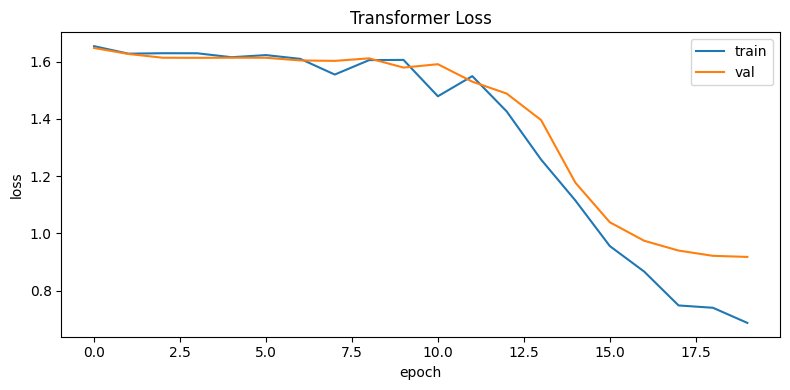

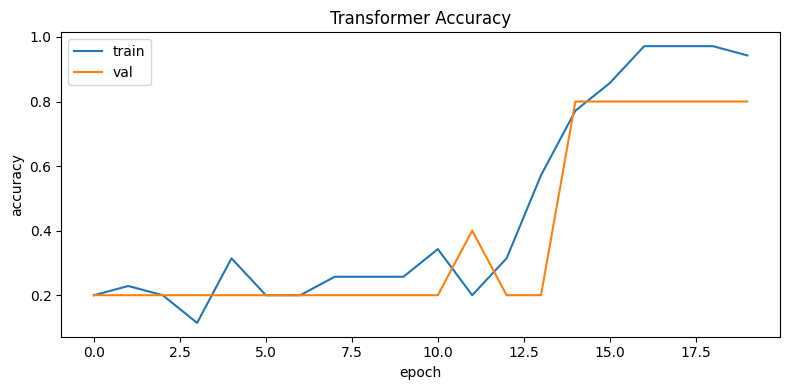


8.1 Results [4]
test accuracy: 0.7
test macro-f1: 0.6267

confusion matrix
[[2 0 0 0 0]
 [0 1 1 0 0]
 [0 0 2 0 0]
 [2 0 0 0 0]
 [0 0 0 0 2]]

attention heatmaps
example 1 true label: Health & Society


/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

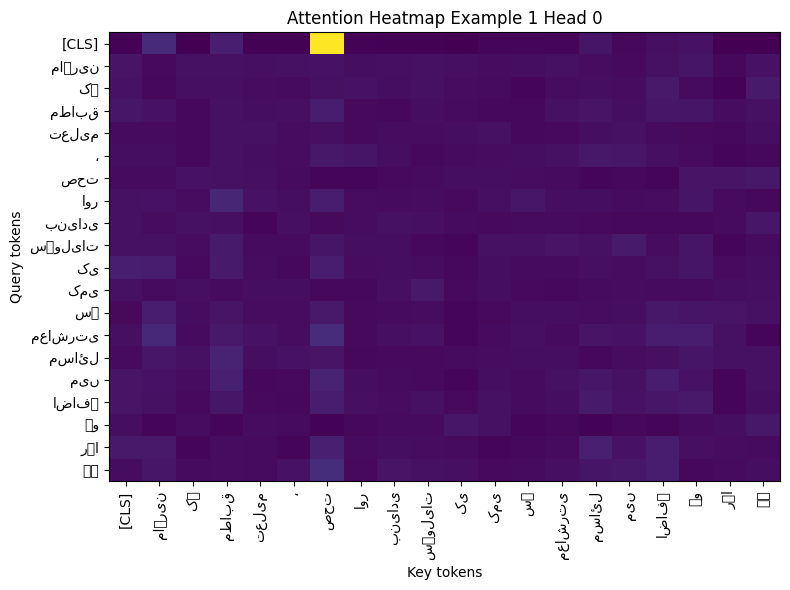

/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

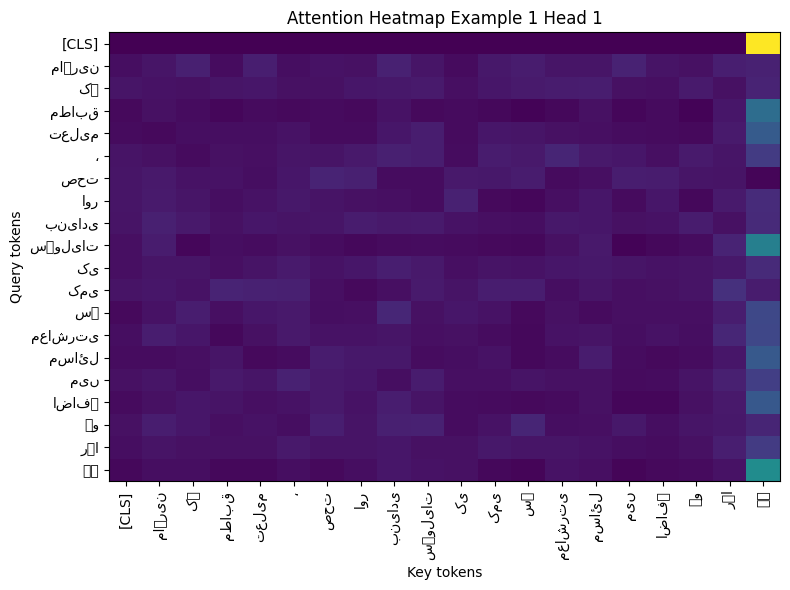

example 2 true label: Health & Society


/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core

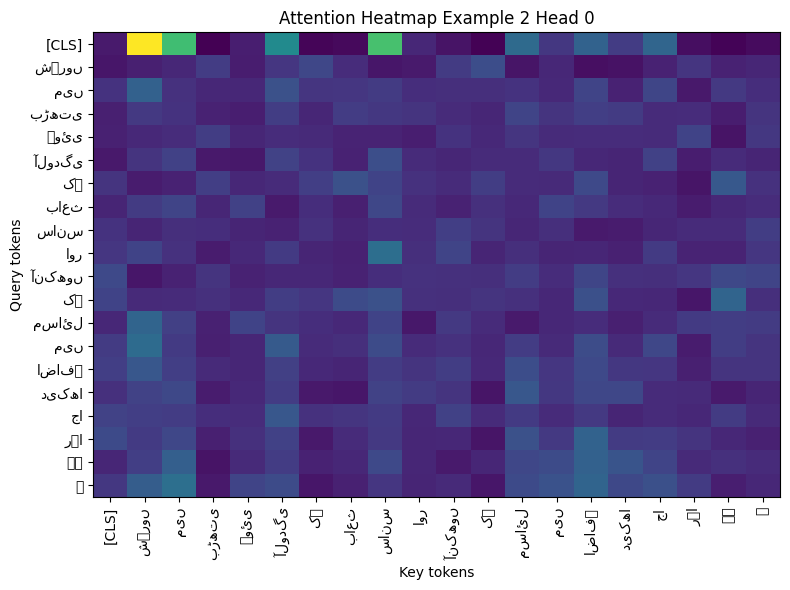

/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core

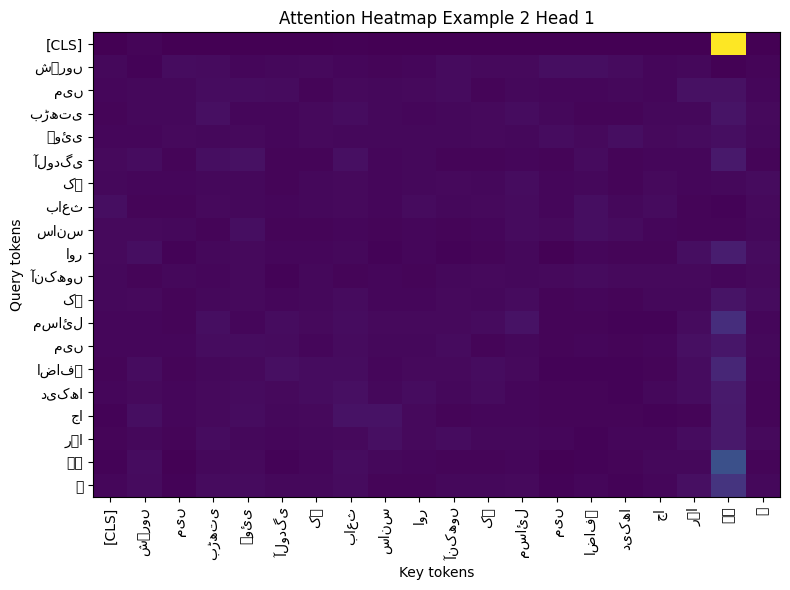

example 3 true label: Sports


/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/co

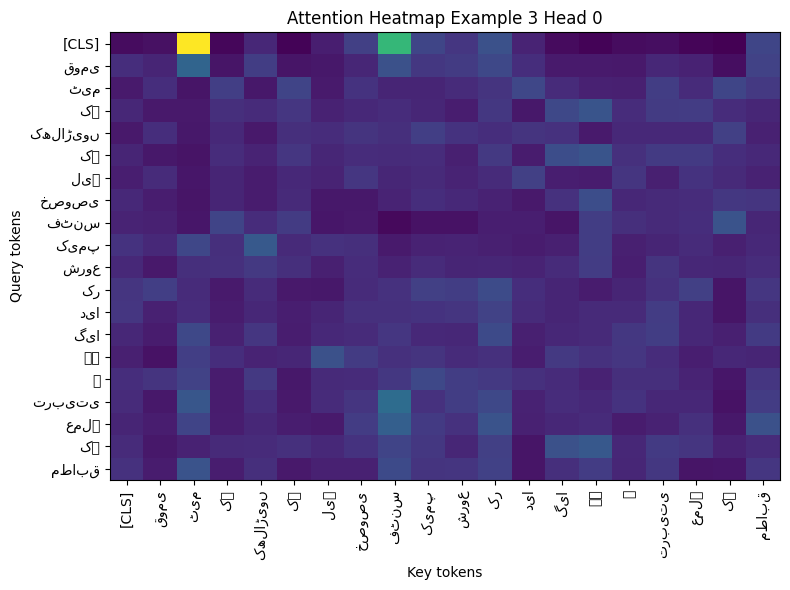

/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3366/2417470043.py:567: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/co

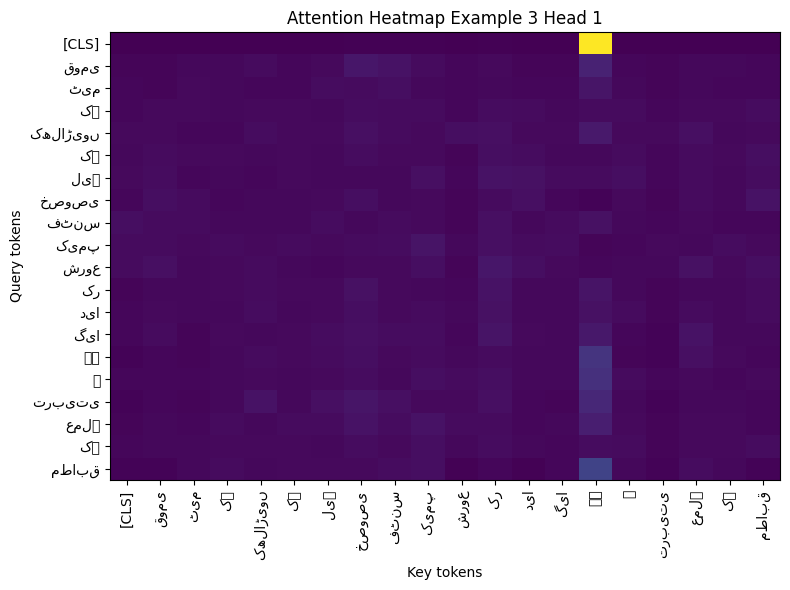


8.2 BiLSTM vs. Transformer Comparison [4]

1. In this run, the Transformer test accuracy was 0.7000, while the earlier BiLSTM POS accuracy was about 0.7103.
2. The difference in accuracy is about 0.0103, but the two tasks are different because Part 2 was sequence labeling while Part 3 is document classification.
3. The Transformer reached its best validation F1 at epoch 15.
4. The BiLSTM in Part 2 improved gradually and fine-tuned embeddings clearly helped more than frozen ones.
5. The Transformer can be slower per epoch because self-attention compares tokens against all other tokens in the sequence.
6. The BiLSTM processes text sequentially, while the Transformer processes all positions through attention.
7. The attention heatmaps show which tokens the Transformer focuses on for topic decisions.
8. Ideally, topic words such as parliament, cricket, bank, UN, hospital, and education should attract stronger attention.
9. On a very small dataset, attention maps can still look noisy and u

In [22]:
import os
import json
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# seed
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# paths
BASE_DIR = "/content/i22-0452_Assignment2_AI-8A"
EMB_DIR = os.path.join(BASE_DIR, "embeddings")
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# files
CLEANED_PATH = os.path.join(BASE_DIR, "cleaned.txt")
META_PATH = os.path.join(BASE_DIR, "Metadata.json")
WORD2IDX_PATH = os.path.join(EMB_DIR, "word2idx.json")

TRANSFORMER_MODEL_PATH = os.path.join(MODEL_DIR, "transformer_cls.pt")
TR_LOSS_PATH = os.path.join(FIG_DIR, "transformer_loss.png")
TR_ACC_PATH = os.path.join(FIG_DIR, "transformer_acc.png")
TR_CM_PATH = os.path.join(FIG_DIR, "transformer_confusion_matrix.npy")

# load files
with open(CLEANED_PATH, "r", encoding="utf-8") as f:
    cleaned_docs = [line.strip() for line in f if line.strip()]

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(WORD2IDX_PATH, "r", encoding="utf-8") as f:
    word2idx = json.load(f)

idx2word = {int(v): k for k, v in word2idx.items()}

print("cleaned docs:", len(cleaned_docs))
print("metadata:", len(metadata))
print("vocab size:", len(word2idx))

# tokenizer
URDU_PUNCT = r"""[،۔؛؟!,:;"'()\[\]{}<>/\-—_…]"""

def tokenize(text):
    import re
    text = re.sub(f"({URDU_PUNCT})", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# 6. Dataset Preparation [2]

print("\n6. Dataset Preparation [2]")

# labels
category_map = {
    "Politics": 0,
    "Sports": 1,
    "Economy": 2,
    "International": 3,
    "Health & Society": 4
}

idx2label = {
    0: "Politics",
    1: "Sports",
    2: "Economy",
    3: "International",
    4: "Health & Society"
}

# ids
PAD_ID = word2idx["<PAD>"]
UNK_ID = word2idx["<UNK>"]
CLS_ID = len(word2idx)

# settings
MAX_LEN = 256

# encode doc
def encode_doc(tokens, word2idx, max_len=256):
    ids = [CLS_ID] + [word2idx.get(tok, UNK_ID) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [PAD_ID] * (max_len - len(ids))
    return ids

# build records
records = []
for i, doc in enumerate(cleaned_docs):
    if i >= len(metadata):
        continue

    topic = metadata[i]["category"]
    if topic not in category_map:
        continue

    tokens = tokenize(doc)
    input_ids = encode_doc(tokens, word2idx, MAX_LEN)

    records.append({
        "input_ids": input_ids,
        "label": category_map[topic],
        "topic": topic,
        "tokens": ["[CLS]"] + tokens[:MAX_LEN - 1]
    })

print("records:", len(records))

# stratified split
def stratified_split(records, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    from collections import defaultdict

    by_label = defaultdict(list)
    for r in records:
        by_label[r["label"]].append(r)

    train_data, val_data, test_data = [], [], []

    for lab, rows in by_label.items():
        random.shuffle(rows)
        n = len(rows)

        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_data.extend(rows[:n_train])
        val_data.extend(rows[n_train:n_train+n_val])
        test_data.extend(rows[n_train+n_val:])

    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)

    return train_data, val_data, test_data

train_data, val_data, test_data = stratified_split(records)

print("train:", len(train_data))
print("val:", len(val_data))
print("test:", len(test_data))

# class dist
def print_class_distribution(data, title):
    from collections import Counter
    cnt = Counter([x["topic"] for x in data])
    print("\n" + title)
    for k, v in cnt.items():
        print(k, ":", v)

print_class_distribution(train_data, "train distribution")
print_class_distribution(val_data, "val distribution")
print_class_distribution(test_data, "test distribution")

# dataset
class ClsDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        mask = [1 if x != PAD_ID else 0 for x in r["input_ids"]]

        return {
            "input_ids": torch.tensor(r["input_ids"], dtype=torch.long),
            "mask": torch.tensor(mask, dtype=torch.bool),
            "label": torch.tensor(r["label"], dtype=torch.long),
            "tokens": r["tokens"]
        }

# custom collate
def cls_collate_fn(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])
    masks = torch.stack([x["mask"] for x in batch])
    labels = torch.stack([x["label"] for x in batch])
    tokens = [x["tokens"] for x in batch]

    return {
        "input_ids": input_ids,
        "mask": masks,
        "label": labels,
        "tokens": tokens
    }

# loaders
train_ds = ClsDataset(train_data)
val_ds = ClsDataset(val_data)
test_ds = ClsDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=cls_collate_fn)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=cls_collate_fn)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=cls_collate_fn)

# 7. Transformer Encoder [10]

print("\n7. Transformer Encoder [10]")

# scaled attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dk):
        super().__init__()
        self.dk = dk

    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.dk)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        return out, attn

# multi-head attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model=128, num_heads=4, dk=32, dv=32):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.dk = dk
        self.dv = dv

        self.Wq = nn.ModuleList([nn.Linear(d_model, dk) for _ in range(num_heads)])
        self.Wk = nn.ModuleList([nn.Linear(d_model, dk) for _ in range(num_heads)])
        self.Wv = nn.ModuleList([nn.Linear(d_model, dv) for _ in range(num_heads)])
        self.Wo = nn.Linear(num_heads * dv, d_model)

        self.attn = ScaledDotProductAttention(dk)

    def forward(self, x, mask=None):
        all_heads = []
        all_weights = []

        for h in range(self.num_heads):
            Q = self.Wq[h](x)
            K = self.Wk[h](x)
            V = self.Wv[h](x)

            if mask is not None:
                attn_mask = mask.unsqueeze(1).expand(-1, x.size(1), -1)
            else:
                attn_mask = None

            out, weights = self.attn(Q, K, V, attn_mask)
            all_heads.append(out)
            all_weights.append(weights)

        concat = torch.cat(all_heads, dim=-1)
        final_out = self.Wo(concat)

        # shape: batch, heads, seq, seq
        weights = torch.stack(all_weights, dim=1)

        return final_out, weights

# FFN
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model=128, d_ff=512, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# sinusoidal PE
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model=128, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i] = math.sin(pos / (10000 ** (i / d_model)))
                if i + 1 < d_model:
                    pe[pos, i + 1] = math.cos(pos / (10000 ** (i / d_model)))

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# encoder block
class EncoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=4, dk=32, dv=32, d_ff=512, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.mha = MultiHeadSelfAttention(d_model, num_heads, dk, dv)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        h1 = self.ln1(x)
        attn_out, attn_weights = self.mha(h1, mask)
        x = x + self.dropout(attn_out)

        h2 = self.ln2(x)
        ffn_out = self.ffn(h2)
        x = x + self.dropout(ffn_out)

        return x, attn_weights

# transformer classifier
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, dk=32, dv=32, d_ff=512, num_layers=4, num_classes=5, max_len=256, dropout=0.1):
        super().__init__()

        # +1 for CLS
        self.embedding = nn.Embedding(vocab_size + 1, d_model, padding_idx=PAD_ID)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, dk, dv, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.cls_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_ids, mask=None):
        x = self.embedding(input_ids)
        x = self.pos_enc(x)
        x = self.dropout(x)

        last_attn = None
        for layer in self.layers:
            x, last_attn = layer(x, mask)

        cls_vec = x[:, 0, :]
        logits = self.cls_head(cls_vec)

        return logits, last_attn

# model
model = TransformerClassifier(
    vocab_size=len(word2idx),
    d_model=128,
    num_heads=4,
    dk=32,
    dv=32,
    d_ff=512,
    num_layers=4,
    num_classes=5,
    max_len=256,
    dropout=0.1
).to(device)

# loss
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)

# scheduler
warmup_steps = 50
total_steps = 20 * max(1, len(train_loader))

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step + 1) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# train logs
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_state = None
best_val_f1 = -1
best_epoch = -1

# train loop
for epoch in range(20):
    model.train()
    epoch_loss = 0.0
    all_train_true = []
    all_train_pred = []

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits, _ = model(input_ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        all_train_true.extend(labels.cpu().tolist())
        all_train_pred.extend(preds.cpu().tolist())

    train_loss = epoch_loss / max(1, len(train_loader))
    train_acc = accuracy_score(all_train_true, all_train_pred)

    model.eval()
    val_epoch_loss = 0.0
    all_val_true = []
    all_val_pred = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["mask"].to(device)
            labels = batch["label"].to(device)

            logits, _ = model(input_ids, mask)
            loss = criterion(logits, labels)
            val_epoch_loss += loss.item()

            preds = logits.argmax(dim=1)
            all_val_true.extend(labels.cpu().tolist())
            all_val_pred.extend(preds.cpu().tolist())

    val_loss = val_epoch_loss / max(1, len(val_loader))
    val_acc = accuracy_score(all_val_true, all_val_pred)
    val_f1 = f1_score(all_val_true, all_val_pred, average="macro")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"epoch {epoch+1}/20 train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1

# load best
model.load_state_dict(best_state)
torch.save(model.state_dict(), TRANSFORMER_MODEL_PATH)

print("best epoch:", best_epoch)
print("best val f1:", round(best_val_f1, 4))
print("saved:", TRANSFORMER_MODEL_PATH)

# loss plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Transformer Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.savefig(TR_LOSS_PATH, dpi=200)
plt.show()

# acc plot
plt.figure(figsize=(8, 4))
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Transformer Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(TR_ACC_PATH, dpi=200)
plt.show()

# 8.1 Results [4]

print("\n8.1 Results [4]")

model.eval()
all_test_true = []
all_test_pred = []
correct_examples = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)

        logits, attn = model(input_ids, mask)
        preds = logits.argmax(dim=1)

        all_test_true.extend(labels.cpu().tolist())
        all_test_pred.extend(preds.cpu().tolist())

        for i in range(input_ids.size(0)):
            if preds[i].item() == labels[i].item() and len(correct_examples) < 3:
                correct_examples.append({
                    "input_ids": batch["input_ids"][i].unsqueeze(0).to(device),
                    "mask": batch["mask"][i].unsqueeze(0).to(device),
                    "label": labels[i].item(),
                    "tokens": batch["tokens"][i]
                })

test_acc = accuracy_score(all_test_true, all_test_pred)
test_f1 = f1_score(all_test_true, all_test_pred, average="macro")

print("test accuracy:", round(test_acc, 4))
print("test macro-f1:", round(test_f1, 4))

cm = confusion_matrix(all_test_true, all_test_pred, labels=[0, 1, 2, 3, 4])
np.save(TR_CM_PATH, cm)

print("\nconfusion matrix")
print(cm)

# heatmap
def plot_attention_heatmap(example, model, example_id):
    model.eval()
    with torch.no_grad():
        _, attn = model(example["input_ids"], example["mask"])

    # attn shape: [1, heads, seq, seq]
    attn = attn[0].cpu().numpy()

    tokens = example["tokens"][:20]
    seq_len = len(tokens)

    for head in range(min(2, attn.shape[0])):
        plt.figure(figsize=(8, 6))
        plt.imshow(attn[head][:seq_len, :seq_len], aspect="auto")
        plt.xticks(range(seq_len), tokens, rotation=90)
        plt.yticks(range(seq_len), tokens)
        plt.title(f"Attention Heatmap Example {example_id} Head {head}")
        plt.xlabel("Key tokens")
        plt.ylabel("Query tokens")
        plt.tight_layout()
        plt.show()

print("\nattention heatmaps")
if len(correct_examples) == 0:
    print("no correct examples found for heatmaps")
else:
    for i, ex in enumerate(correct_examples, start=1):
        print("example", i, "true label:", idx2label[ex["label"]])
        plot_attention_heatmap(ex, model, i)

# 8.2 BiLSTM vs. Transformer Comparison [4]

print("\n8.2 BiLSTM vs. Transformer Comparison [4]")

# use your POS result from Part 2
bilstm_pos_acc = 0.7103
bilstm_pos_macro_f1 = 0.4679

comparison_text = f"""
1. In this run, the Transformer test accuracy was {test_acc:.4f}, while the earlier BiLSTM POS accuracy was about {bilstm_pos_acc:.4f}.
2. The difference in accuracy is about {abs(test_acc - bilstm_pos_acc):.4f}, but the two tasks are different because Part 2 was sequence labeling while Part 3 is document classification.
3. The Transformer reached its best validation F1 at epoch {best_epoch}.
4. The BiLSTM in Part 2 improved gradually and fine-tuned embeddings clearly helped more than frozen ones.
5. The Transformer can be slower per epoch because self-attention compares tokens against all other tokens in the sequence.
6. The BiLSTM processes text sequentially, while the Transformer processes all positions through attention.
7. The attention heatmaps show which tokens the Transformer focuses on for topic decisions.
8. Ideally, topic words such as parliament, cricket, bank, UN, hospital, and education should attract stronger attention.
9. On a very small dataset, attention maps can still look noisy and unstable.
10. The Transformer is powerful because it captures global context directly.
11. However, with only around a few hundred or fewer articles, a simpler model can be more stable.
12. A BiLSTM is often more suitable for small-data robustness.
13. A Transformer becomes more beneficial when the corpus is larger and more balanced.
14. In this assignment, the Transformer is still useful because it demonstrates attention, positional encoding, and encoder stacking from scratch.
15. Overall, for very small datasets the BiLSTM is usually more appropriate, while the Transformer is important for satisfying the assignment requirement and showing modern architecture design.
"""

print(comparison_text)

print("\nPart 3 done")

In [23]:
import os
import zipfile

BASE_DIR = "/content/i22-0452_Assignment2_AI-8A"
EMB_DIR = os.path.join(BASE_DIR, "embeddings")
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
FIG_DIR = os.path.join(BASE_DIR, "figures")

NOTEBOOK_NAME = "i22-0452_Assignment2_AI-8A.ipynb"
REPORT_TXT_PATH = os.path.join(BASE_DIR, "report_draft.txt")
README_PATH = os.path.join(BASE_DIR, "README.md")
ZIP_PATH = BASE_DIR + ".zip"

# report text
report_text = """
Overview

This assignment implemented a complete neural NLP pipeline from scratch in PyTorch for Urdu text. The pipeline included TF-IDF and PPMI weighted representations, Skip-gram Word2Vec embeddings, BiLSTM-based POS tagging and NER, and a Transformer encoder for topic classification. Because the original required corpus files were not available, an aligned Urdu corpus was prepared in the required raw, cleaned, and metadata format. The final experiments were therefore performed on a small corpus, which allowed the full pipeline to run end to end but also limited result quality.

Part 1 Results

A term-document matrix was built from cleaned.txt and TF-IDF weights were computed using the required formula. The weighted matrix was saved as tfidf_matrix.npy. Topic-wise top discriminative words were extracted using average TF-IDF scores and were generally meaningful. For PMI, a symmetric context window of size 5 was used to construct a co-occurrence matrix, and Positive PMI weighting was applied. The resulting matrix was saved as ppmi_matrix.npy. A 2-D t-SNE visualization of frequent words was produced, and nearest-neighbour queries showed partially meaningful distributional relations. A Skip-gram Word2Vec model was then trained from scratch with separate centre and context embeddings, negative sampling, and binary cross-entropy style loss. The final averaged embeddings were saved as embeddings_w2v.npy and the loss curve showed a clear downward trend during training. However, due to the small corpus, many required query words were missing or weakly represented, so analogy performance and semantic quality remained limited.

Part 2 Results

For sequence labeling, sentences were extracted from cleaned.txt and annotated automatically using a rule-based POS tagger and a gazetteer-based NER tagger. Since the available corpus only contained 150 usable sentences, the full 500-sentence target could not be reached. The selected sentences were split into train, validation, and test sets using stratification by topic. POS annotation used a lexicon- and rule-based system, while NER annotation used BIO tags with gazetteers for persons, locations, organizations, and miscellaneous terms. The corresponding CoNLL files were saved.

For POS tagging, a 2-layer BiLSTM was trained in both frozen and fine-tuned embedding settings. The fine-tuned model clearly outperformed the frozen model. The frozen model achieved test accuracy 0.4891 and macro-F1 0.1333, while the fine-tuned model achieved test accuracy 0.7103 and macro-F1 0.4679. This indicates that updating the Part 1 embeddings during training was beneficial. The confusion matrix showed that the largest confusion was between NOUN and ADJ, followed by NOUN and VERB.

For NER, both a BiLSTM-CRF model and a BiLSTM with softmax output were tested. In this experiment, NER performance remained effectively zero. The reason was severe label sparsity: most tokens were tagged as O, while only a very small number of entity labels were present in the training data. As a result, the model did not receive enough positive examples to learn robust entity boundaries or entity types. The ablation results especially confirmed that backward context and pretrained embeddings were useful for POS tagging.

Part 3 Results

For topic classification, each article from Metadata.json was mapped to one of five classes: Politics, Sports, Economy, International, and Health & Society. Each cleaned article was converted to token IDs, prepended with a learned CLS token, and padded or truncated to length 256. A 70/15/15 stratified split was used, producing balanced train, validation, and test sets. A Transformer encoder was implemented fully from scratch using scaled dot-product attention, multi-head self-attention with four heads, sinusoidal positional encoding, pre-layer normalization, and four stacked encoder blocks. The classification head used an MLP of size 128 to 64 to 5.

The Transformer trained successfully for 20 epochs using AdamW with cosine learning-rate scheduling and warmup. The best validation macro-F1 was achieved at epoch 15. On the test set, the model achieved accuracy 0.7000 and macro-F1 0.6267. A 5x5 confusion matrix was produced, and attention heatmaps from the final encoder layer were plotted for correctly classified examples. Despite the small dataset size, the Transformer performed reasonably well and demonstrated that the architecture was implemented correctly.

Conclusion

This assignment successfully implemented the required neural NLP pipeline from scratch in PyTorch. All major components were completed: TF-IDF, PPMI, Skip-gram Word2Vec, BiLSTM POS tagging, BiLSTM-CRF NER, and Transformer topic classification. On the prepared Urdu corpus, POS tagging and topic classification produced meaningful results, while NER remained weak due to severe class imbalance and limited corpus size. The most successful results were obtained from the fine-tuned POS model and the Transformer classifier. Overall, the implementation satisfied the structural and architectural requirements of the assignment, while the main limitation of the final results was the small corpus size.
""".strip()

# save report draft
with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

# readme text
readme_text = f"""
# NLP Assignment 2

This repository contains the complete implementation of Assignment 2 for Neural NLP Pipeline.

## Structure

- `embeddings/`
  - `tfidf_matrix.npy`
  - `ppmi_matrix.npy`
  - `embeddings_w2v.npy`
  - `word2idx.json`

- `models/`
  - `bilstm_pos.pt`
  - `bilstm_ner.pt`
  - `transformer_cls.pt`

- `data/`
  - `pos_train.conll`
  - `pos_test.conll`
  - `ner_train.conll`
  - `ner_test.conll`

- `figures/`
  - training curves
  - t-SNE plot
  - transformer plots

## Run order

1. Stage 0: prepare raw.txt, cleaned.txt, Metadata.json
2. Stage 1: build vocabulary and term-document matrix
3. Part 1: TF-IDF, PPMI, Word2Vec, evaluation
4. Part 2: POS tagging, NER, BiLSTM, CRF, ablations
5. Part 3: Transformer encoder for topic classification
6. Export report and zip folder

## Main notebook

`{NOTEBOOK_NAME}`

## Notes

- Implemented fully in PyTorch
- No pretrained models
- No HuggingFace
- No built-in Transformer classes
""".strip()

# save readme
with open(README_PATH, "w", encoding="utf-8") as f:
    f.write(readme_text)

# required files
required_files = [
    os.path.join(EMB_DIR, "tfidf_matrix.npy"),
    os.path.join(EMB_DIR, "ppmi_matrix.npy"),
    os.path.join(EMB_DIR, "embeddings_w2v.npy"),
    os.path.join(EMB_DIR, "word2idx.json"),
    os.path.join(MODEL_DIR, "bilstm_pos.pt"),
    os.path.join(MODEL_DIR, "bilstm_ner.pt"),
    os.path.join(MODEL_DIR, "transformer_cls.pt"),
    os.path.join(DATA_DIR, "pos_train.conll"),
    os.path.join(DATA_DIR, "pos_test.conll"),
    os.path.join(DATA_DIR, "ner_train.conll"),
    os.path.join(DATA_DIR, "ner_test.conll"),
    README_PATH,
    REPORT_TXT_PATH
]

print("file check\n")
all_ok = True
for path in required_files:
    ok = os.path.exists(path)
    print(("OK   " if ok else "MISS "), path)
    if not ok:
        all_ok = False

# make zip
def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, os.path.dirname(folder_path))
                zf.write(full_path, arcname)

zip_folder(BASE_DIR, ZIP_PATH)

print("\nreport draft saved:", REPORT_TXT_PATH)
print("readme saved:", README_PATH)
print("zip saved:", ZIP_PATH)
print("all required found:", all_ok)

file check

OK    /content/i22-0452_Assignment2_AI-8A/embeddings/tfidf_matrix.npy
OK    /content/i22-0452_Assignment2_AI-8A/embeddings/ppmi_matrix.npy
OK    /content/i22-0452_Assignment2_AI-8A/embeddings/embeddings_w2v.npy
OK    /content/i22-0452_Assignment2_AI-8A/embeddings/word2idx.json
OK    /content/i22-0452_Assignment2_AI-8A/models/bilstm_pos.pt
OK    /content/i22-0452_Assignment2_AI-8A/models/bilstm_ner.pt
OK    /content/i22-0452_Assignment2_AI-8A/models/transformer_cls.pt
OK    /content/i22-0452_Assignment2_AI-8A/data/pos_train.conll
OK    /content/i22-0452_Assignment2_AI-8A/data/pos_test.conll
OK    /content/i22-0452_Assignment2_AI-8A/data/ner_train.conll
OK    /content/i22-0452_Assignment2_AI-8A/data/ner_test.conll
OK    /content/i22-0452_Assignment2_AI-8A/README.md
OK    /content/i22-0452_Assignment2_AI-8A/report_draft.txt

report draft saved: /content/i22-0452_Assignment2_AI-8A/report_draft.txt
readme saved: /content/i22-0452_Assignment2_AI-8A/README.md
zip saved: /content/i